# 🇻🇳 Phân Loại Cảm Xúc Tiếng Việt — So Sánh 3 Mô Hình

## Mục tiêu
Notebook này xây dựng và so sánh **3 mô hình phân loại cảm xúc** cho văn bản tiếng Việt:

| # | Mô hình | Loại |
|---|---------|------|
| 1 | **TF-IDF + SVM** | Machine Learning cổ điển |
| 2 | **TF-IDF + Logistic Regression** | Machine Learning cổ điển |
| 3 | **PhoBERT** | Deep Learning / Transformer |

## Bài toán
- **Input:** Bình luận tiếng Việt (từ file `final_data.csv`)
- **Output:** Một trong 3 nhãn → `negative`, `neutral`, `positive`
- **Thách thức:** Dữ liệu mất cân bằng nghiêm trọng (positive >> negative >> neutral)

## Cấu trúc pipeline



In [ ]:
# ============================================================
# CELL 2 — CÀI ĐẶT THƯ VIỆN
# ============================================================
# Chạy cell này đầu tiên. Runtime sẽ cần restart sau khi cài xong.

!pip install -q transformers datasets accelerate sentencepiece
!pip install -q underthesea pyvi
!pip install -q imbalanced-learn
!pip install -q scikit-learn pandas matplotlib seaborn joblib

print("✅ Đã cài xong toàn bộ thư viện.")
print("⚠️  Nếu đây là lần đầu chạy, hãy vào Runtime → Restart session, sau đó chạy lại từ CELL 3.")

✅ Đã cài xong toàn bộ thư viện.
⚠️  Nếu đây là lần đầu chạy, hãy vào Runtime → Restart session, sau đó chạy lại từ CELL 3.


In [1]:
# ============================================================
# CELL 3 — IMPORT THƯ VIỆN
# ============================================================

import os
import re
import time
import warnings
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
    log_loss, hinge_loss
)
from sklearn.utils import shuffle, class_weight
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)
from datasets import Dataset

warnings.filterwarnings("ignore")
print("✅ Import thành công.")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Import thành công.
PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [14]:
# ============================================================
# CELL 4 — CẤU HÌNH ĐƯỜNG DẪN / SEED / DEVICE (ĐÃ ĐỔI SANG DISTILBERT)
# ============================================================

# ---- Seed để tái tạo kết quả ----
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
set_seed(RANDOM_SEED)

# ---- Device ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ---- Đường dẫn dữ liệu ----
BASE_DIR = "/content/drive/MyDrive/content"  # Thay đổi nếu cần

DATA_PATH          = f"{BASE_DIR}/final_data.csv"
CLEANED_CACHE_PATH = f"{BASE_DIR}/data_cleaned_ml_cache.csv"
MODEL_SAVE_DIR     = f"{BASE_DIR}/saved_models"

# Đổi tên thư mục để không bị lẫn với PhoBERT cũ
DISTILBERT_CKPT_DIR  = f"{BASE_DIR}/distilbert_checkpoints"
DISTILBERT_FINAL_DIR = f"{BASE_DIR}/distilbert_final"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(DISTILBERT_CKPT_DIR, exist_ok=True)
os.makedirs(DISTILBERT_FINAL_DIR, exist_ok=True)

# ---- Nhãn ----
LABEL_LIST   = ["negative", "neutral", "positive"]
LABEL2ID     = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL     = {i: l for i, l in enumerate(LABEL_LIST)}
NUM_LABELS   = len(LABEL_LIST)

# ---- DistilBERT checkpoint ----
DISTILBERT_MODEL_NAME = "distilbert-base-multilingual-cased"

# ---- Tham số DistilBERT ----
DISTILBERT_MAX_LEN        = 256  # Tăng lên 256 để cover hết các đánh giá dài
DISTILBERT_BATCH_SIZE     = 16
DISTILBERT_EPOCHS         = 10
DISTILBERT_LR             = 2e-5
DISTILBERT_WEIGHT_DECAY   = 0.05 # Regularization vừa phải
DISTILBERT_WARMUP_RATIO   = 0.1

print("✅ Cấu hình hoàn tất.")
print(f"  DATA_PATH: {DATA_PATH}")
print(f"  DISTILBERT_CKPT_DIR: {DISTILBERT_CKPT_DIR}")
print(f"  Labels: {LABEL_LIST}")

Device: cuda
✅ Cấu hình hoàn tất.
  DATA_PATH: /content/drive/MyDrive/content/final_data.csv
  DISTILBERT_CKPT_DIR: /content/drive/MyDrive/content/distilbert_checkpoints
  Labels: ['negative', 'neutral', 'positive']


In [15]:
# ============================================================
# CELL 5 — LOAD DỮ LIỆU
# ============================================================

# Nếu upload trực tiếp lên Colab thì dùng lệnh dưới
# from google.colab import files
# uploaded = files.upload()  # upload final_data.csv
DATA_PATH = list(uploaded.keys())[0]

df_raw = pd.read_csv(DATA_PATH)

print(f"✅ Đã load dữ liệu: {df_raw.shape[0]} dòng, {df_raw.shape[1]} cột")
print(f"\nTên cột: {df_raw.columns.tolist()}")
print(f"\n5 dòng đầu:")
display(df_raw.head())

✅ Đã load dữ liệu: 12736 dòng, 4 cột

Tên cột: ['comment', 'source', 'cleaned_comment', 'final_label']

5 dòng đầu:


,comment,source,cleaned_comment,final_label
0,Good,booking,good,positive
1,"phòng đẹp,đồ ăn ngon",booking,"phòng đẹp , đồ ăn ngon",positive
2,Bình thường,booking,bình_thường,neutral
3,nhân viên nhiệt tình cute,booking,nhân_viên nhiệt_tình cute,positive
4,"Nhân viên thân thiện nhiệt tình, địa điểm tốt",booking,"nhân_viên thân_thiện nhiệt_tình , địa_điểm tốt",positive


  TỔNG QUAN DỮ LIỆU
Shape: (12736, 4)

Kiểu dữ liệu từng cột:
comment            object
source             object
cleaned_comment    object
final_label        object
dtype: object

Số dòng null theo cột:
comment            0
source             0
cleaned_comment    1
final_label        0
dtype: int64

Số dòng trùng lặp: 1210

Dữ liệu sau khi bỏ trùng lặp :                                                  comment   source  \
0                                                   Good  booking   
1                                   phòng đẹp,đồ ăn ngon  booking   
2                                            Bình thường  booking   
3                              nhân viên nhiệt tình cute  booking   
4          Nhân viên thân thiện nhiệt tình, địa điểm tốt  booking   
...                                                  ...      ...   
11521  Hôm mình đi là ngày 9/9\nTrong lúc mình check ...    agoda   
11522  Điểm trừ: Phòng dọn không sạch, dép nằm dưới g...    agoda   
11523  Giá phòng rẻ ,

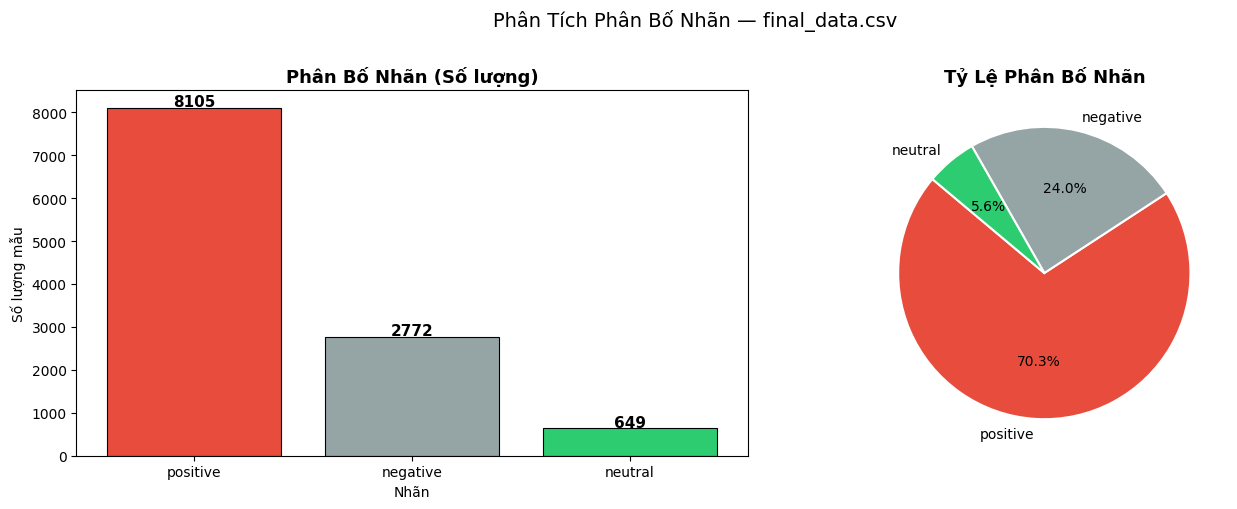


Độ dài trung bình comment (từ):
              count   mean    std  min  25%   50%   75%    max
final_label                                                   
negative     2772.0  29.91  46.07  1.0  7.0  15.0  33.0  636.0
neutral       649.0  12.53  17.99  1.0  4.0   7.0  16.0  296.0
positive     8105.0  35.21  44.36  1.0  9.0  21.0  44.0  719.0

⚠️  Nhận xét:
  - Dữ liệu MẤT CÂN BẰNG NGHIÊM TRỌNG:
    positive=8105, negative=2772, neutral=649
  - Nhãn 'neutral' là lớp THIỂU SỐ nhất, cần xử lý cẩn thận.


In [16]:
# ============================================================
# CELL 6 — KHÁM PHÁ DỮ LIỆU BAN ĐẦU (EDA)
# ============================================================

print("=" * 55)
print("  TỔNG QUAN DỮ LIỆU")
print("=" * 55)
print(f"Shape: {df_raw.shape}")
print(f"\nKiểu dữ liệu từng cột:")
print(df_raw.dtypes)

print(f"\nSố dòng null theo cột:")
print(df_raw.isnull().sum())

print(f"\nSố dòng trùng lặp: {df_raw.duplicated().sum()}")
df_raw = df_raw.drop_duplicates().reset_index(drop=True)
print(f"\nDữ liệu sau khi bỏ trùng lặp : {df_raw}")
print(f"\nPhân bố nhãn (final_label):")
label_counts = df_raw["final_label"].value_counts()
print(label_counts)
print(f"\nTỷ lệ phần trăm:")
print((label_counts / len(df_raw) * 100).round(2).astype(str) + "%")

# ---- Vẽ biểu đồ phân bố nhãn ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_title("Phân Bố Nhãn (Số lượng)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Nhãn")
axes[0].set_ylabel("Số lượng mẫu")
for i, (label, count) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, count + 30, str(count), ha="center", fontsize=11, fontweight="bold")

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Tỷ Lệ Phân Bố Nhãn", fontsize=13, fontweight="bold")

plt.suptitle("Phân Tích Phân Bố Nhãn — final_data.csv", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ---- Phân tích độ dài comment ----
df_raw["comment_len"] = df_raw["comment"].astype(str).apply(lambda x: len(x.split()))
print("\nĐộ dài trung bình comment (từ):")
print(df_raw.groupby("final_label")["comment_len"].describe().round(2))

print("\n⚠️  Nhận xét:")
print(f"  - Dữ liệu MẤT CÂN BẰNG NGHIÊM TRỌNG:")
print(f"    positive={label_counts.get('positive', 0)}, "
      f"negative={label_counts.get('negative', 0)}, "
      f"neutral={label_counts.get('neutral', 0)}")
print(f"  - Nhãn 'neutral' là lớp THIỂU SỐ nhất, cần xử lý cẩn thận.")

In [17]:
# ============================================================
# CELL 7 — KIỂM TRA / TẠO CLEANED CACHE
# ============================================================
# Lưu ý: cleaned_comment trong file gốc đã có word segmentation tiếng Việt
# (dấu gạch dưới: "nhân_viên", "thân_thiện"). Đây là định dạng chuẩn cho PhoBERT.
# Ta sẽ tận dụng cột này cho PhoBERT, và xây dựng thêm pipeline làm sạch
# cho ML (TF-IDF) với loại bỏ stopwords và chuẩn hóa thêm.

def normalize_text_basic(text):
    """
    Tiền xử lý cơ bản: unicode → lowercase → bỏ URL/mention → bỏ ký tự đặc biệt → strip khoảng trắng.
    Dùng cho TF-IDF ML pipeline.
    Không xóa stopwords ở đây — sẽ xử lý sau.
    """
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = str(text)
    # Chuẩn hóa unicode
    text = unicodedata.normalize("NFC", text)
    # Lowercase
    text = text.lower()
    # Xóa URL
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # Xóa mention @user
    text = re.sub(r"@\w+", " ", text)
    # Xóa ký tự đặc biệt — giữ chữ cái Unicode (tiếng Việt), số, khoảng trắng, gạch dưới
    text = re.sub(r"[^\w\s]", " ", text)
    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ---- Kiểm tra cache ----
if os.path.exists(CLEANED_CACHE_PATH):
    print(f"📂 Tìm thấy file cache: {CLEANED_CACHE_PATH}")
    df = pd.read_csv(CLEANED_CACHE_PATH)
    print(f"   Đã load: {df.shape[0]} dòng")
else:
    print("⚙️  Không tìm thấy cache. Đang làm sạch dữ liệu từ đầu...")

    df = df_raw.copy()

    # 1. Xóa dòng null ở comment hoặc final_label
    df = df.dropna(subset=["comment", "final_label"])

    # 2. Xóa dòng trùng lặp (giữ lần đầu tiên)
    df = df.drop_duplicates(subset=["comment", "final_label"]).reset_index(drop=True)
    print(f"   Sau khi xóa null và trùng lặp: {df.shape[0]} dòng")

    # 3. Giữ chỉ nhãn hợp lệ
    valid_labels = set(LABEL_LIST)
    df = df[df["final_label"].isin(valid_labels)].reset_index(drop=True)
    print(f"   Sau khi lọc nhãn hợp lệ: {df.shape[0]} dòng")

    # 4. Điền cleaned_comment nếu bị null bằng normalize comment gốc
    df["cleaned_comment"] = df["cleaned_comment"].fillna(df["comment"].apply(normalize_text_basic))

    # 5. Tạo thêm cột text_normalized cho pipeline ML (lowercase + clean thêm từ comment gốc)
    #    Lý do: cleaned_comment đã có word segmentation (gạch dưới) rất phù hợp cho PhoBERT,
    #    nhưng ta cần version normalize thêm (bỏ khoảng trắng thừa) cho TF-IDF.
    df["text_for_ml_raw"] = df["comment"].apply(normalize_text_basic)

    # 6. Xóa dòng text rỗng sau khi làm sạch
    df = df[df["text_for_ml_raw"].str.strip() != ""].reset_index(drop=True)
    print(f"   Sau khi xóa text rỗng: {df.shape[0]} dòng")

    # 7. Lưu cache
    df.to_csv(CLEANED_CACHE_PATH, index=False)
    print(f"✅ Đã lưu cache: {CLEANED_CACHE_PATH}")

print(f"\nPhân bố nhãn sau làm sạch:")
print(df["final_label"].value_counts())

📂 Tìm thấy file cache: /content/drive/MyDrive/content/data_cleaned_ml_cache.csv
   Đã load: 11476 dòng

Phân bố nhãn sau làm sạch:
final_label
positive    8067
negative    2769
neutral      640
Name: count, dtype: int64


In [18]:
# ============================================================
# CELL 8 — TIỀN XỬ LÝ CHO ML
# ============================================================

# ---- Tải Vietnamese stopwords ----
VI_STOPWORDS = set()

# Cách 1: Thử tải từ underthesea
try:
    from underthesea import word_tokenize as uts_tokenize
    # underthesea không có stopwords list trực tiếp, dùng list thủ công
    _uts_ok = True
    print("✅ underthesea available.")
except ImportError:
    _uts_ok = False
    print("⚠️  underthesea không có. Sẽ dùng pyvi hoặc fallback.")

# Danh sách stopwords tiếng Việt thường dùng
_VI_SW_LIST = [
    "và", "của", "các", "có", "được", "trong", "là", "với", "cho",
    "từ", "đã", "khi", "về", "tại", "vì", "thì", "mà", "hay",
    "hoặc", "nhưng", "nếu", "vậy", "đó", "này", "kia", "đây",
    "một", "hai", "ba", "nhiều", "những", "các", "để", "bị",
    "rất", "cũng", "đều", "thêm", "lại", "đến", "lên", "xuống",
    "ra", "vào", "theo", "qua", "sau", "trước", "nên", "phải",
    "bởi", "do", "mình", "tôi", "bạn", "chúng", "họ", "nó",
    "ở", "tại", "trên", "dưới", "giữa", "ngoài", "trong",
    "không", "chưa", "đang", "sẽ", "đã", "còn", "cần", "muốn"
]

# Thử tải từ file nếu có (pyvi hoặc file external)
try:
    from pyvi import ViTokenizer
    _pyvi_ok = True
    print("✅ pyvi available.")
except ImportError:
    _pyvi_ok = False
    print("⚠️  pyvi không có. Sử dụng fallback đơn giản.")

VI_STOPWORDS = set(_VI_SW_LIST)

# Thêm phiên bản có gạch dưới (sau segmentation: nhân_viên)
VI_STOPWORDS.update({w.replace(" ", "_") for w in _VI_SW_LIST})
print(f"   Tổng stopwords tiếng Việt: {len(VI_STOPWORDS)}")


def preprocess_for_ml(text):
    """
    Tiền xử lý văn bản cho TF-IDF ML pipeline.
    Input: cleaned_comment (đã có word segmentation)
    Output: chuỗi đã lowercase, bỏ ký tự đặc biệt, bỏ stopwords
    """
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = str(text).lower()
    # Bỏ URL (phòng trường hợp còn sót)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # Bỏ ký tự đặc biệt, giữ chữ cái Unicode và gạch dưới (word segmentation)
    text = re.sub(r"[^\w\s]", " ", text)
    # Bỏ số (option: có thể giữ lại tùy bài toán)
    text = re.sub(r"\b\d+\b", " ", text)
    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()
    # Bỏ stopwords
    words = text.split()
    words = [w for w in words if w not in VI_STOPWORDS]
    return " ".join(words)


# Áp dụng tiền xử lý ML — dùng cleaned_comment làm đầu vào
print("⚙️  Đang tiền xử lý cho ML...")
df["text_ml"] = df["cleaned_comment"].apply(preprocess_for_ml)

# Fallback: nếu text_ml rỗng thì dùng comment gốc
empty_ml_mask = df["text_ml"].str.strip() == ""
if empty_ml_mask.sum() > 0:
    print(f"   {empty_ml_mask.sum()} dòng text_ml rỗng → fallback từ comment gốc")
    df.loc[empty_ml_mask, "text_ml"] = df.loc[empty_ml_mask, "comment"].apply(preprocess_for_ml)

# Xóa dòng vẫn còn rỗng sau fallback
df = df[df["text_ml"].str.strip() != ""].reset_index(drop=True)
print(f"✅ Hoàn tất. Còn {len(df)} dòng sau tiền xử lý ML.")

# In ví dụ trước/sau
print("\n📋 Ví dụ tiền xử lý ML (3 dòng):")
print(f"{'ORIGINAL':<45} | {'CLEANED_COMMENT':<45} | {'TEXT_ML':<45}")
print("-" * 140)
for _, row in df.sample(3, random_state=42).iterrows():
    orig    = str(row["comment"])[:43]
    cleaned = str(row["cleaned_comment"])[:43]
    text_ml = str(row["text_ml"])[:43]
    print(f"{orig:<45} | {cleaned:<45} | {text_ml:<45}")

⚠️  underthesea không có. Sẽ dùng pyvi hoặc fallback.
⚠️  pyvi không có. Sử dụng fallback đơn giản.
   Tổng stopwords tiếng Việt: 69
⚙️  Đang tiền xử lý cho ML...
   32 dòng text_ml rỗng → fallback từ comment gốc
✅ Hoàn tất. Còn 11453 dòng sau tiền xử lý ML.

📋 Ví dụ tiền xử lý ML (3 dòng):
ORIGINAL                                      | CLEANED_COMMENT                               | TEXT_ML                                      
--------------------------------------------------------------------------------------------------------------------------------------------
Điểm trừ duy nhất là chỗ đổ xe hơi bất tiện   | điểm trừ duy_nhất là chỗ đổ xe_hơi bất_tiện   | điểm trừ duy_nhất chỗ đổ xe_hơi bất_tiện     
Tiếp tân nam không thân thiện                 | tiếp_tân_nam không thân_thiện                 | tiếp_tân_nam thân_thiện                      
Khách sạn sạch sẽ, thoáng mát, nhân viên th   | khách_sạn sạch_sẽ , thoáng mát , nhân_viên    | khách_sạn sạch_sẽ thoáng mát nhân_viên thân  

final_label
positive    8064
negative    2755
neutral      634
Name: count, dtype: int64

Tỷ lệ phần trăm:
final_label
positive    69.96%
negative     23.9%
neutral       5.5%
Name: count, dtype: object
Tổng nhãn: 11453


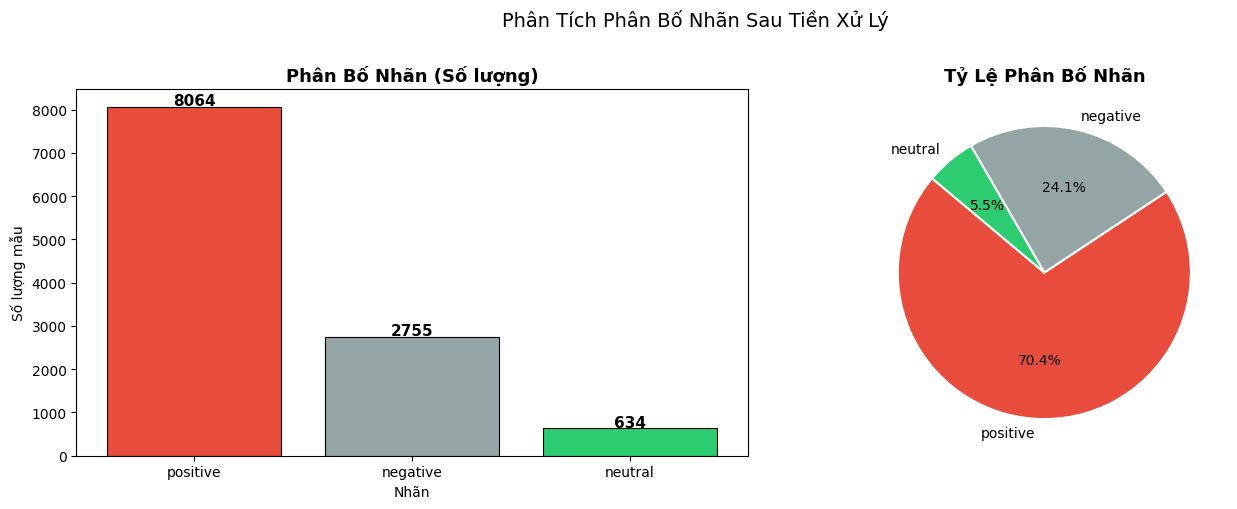

In [23]:
label_counts = df["final_label"].value_counts()
print(label_counts)
print(f"\nTỷ lệ phần trăm:")
print((label_counts / len(df_raw) * 100).round(2).astype(str) + "%")
print("Tổng nhãn:",sum(label_counts))
# ---- Vẽ biểu đồ phân bố nhãn ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_title("Phân Bố Nhãn (Số lượng)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Nhãn")
axes[0].set_ylabel("Số lượng mẫu")
for i, (label, count) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, count + 30, str(count), ha="center", fontsize=11, fontweight="bold")

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Tỷ Lệ Phân Bố Nhãn", fontsize=13, fontweight="bold")

plt.suptitle("Phân Tích Phân Bố Nhãn Sau Tiền Xử Lý", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [19]:
# ============================================================
# CELL 9 — TIỀN XỬ LÝ CHO DISTILBERT
# ============================================================
# DistilBERT (distilbert-base-multilingual-cased) KHÔNG yêu cầu word segmentation
# có dấu gạch dưới giống như PhoBERT. Nó xử lý tốt văn bản tiếng Việt tự nhiên.
#
# Những gì ta làm:
#   - Chuẩn hóa unicode NFC
#   - Lowercase
#   - XÓA DẤU GẠCH DƯỚI (_) từ word segmentation cũ để đưa về câu bình thường.
#   - Bỏ URL và mention (không có ngữ nghĩa)
#   - KHÔNG xóa stopwords (DistilBERT cần ngữ cảnh đầy đủ)

def preprocess_for_distilbert(text):
    """
    Tiền xử lý nhẹ cho DistilBERT.
    Xóa dấu gạch dưới để trả về định dạng câu bình thường.
    """
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.lower()

    # Bỏ URL
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # Bỏ mention
    text = re.sub(r"@\w+", " ", text)

    # XÓA GẠCH DƯỚI (RẤT QUAN TRỌNG CHO DISTILBERT)
    text = text.replace("_", " ")

    # Bỏ ký tự đặc biệt ngoài chữ cái, số, khoảng trắng
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("⚙️  Đang tiền xử lý cho DistilBERT...")
df["text_distilbert"] = df["cleaned_comment"].apply(preprocess_for_distilbert)

# Fallback nếu rỗng
empty_db_mask = df["text_distilbert"].str.strip() == ""
if empty_db_mask.sum() > 0:
    print(f"   {empty_db_mask.sum()} dòng rỗng → fallback từ comment gốc")
    df.loc[empty_db_mask, "text_distilbert"] = df.loc[empty_db_mask, "comment"].apply(preprocess_for_distilbert)

# Xóa dòng vẫn còn rỗng sau fallback (nếu có)
df = df[df["text_distilbert"].str.strip() != ""].reset_index(drop=True)

print(f"✅ Hoàn tất. Cột text_distilbert sẵn sàng.")

# In ví dụ trước/sau
print("\n📋 Ví dụ tiền xử lý DistilBERT (3 dòng):")
print(f"{'CLEANED_COMMENT':<50} | {'TEXT_DISTILBERT':<50}")
print("-" * 105)
for _, row in df.sample(3, random_state=99).iterrows():
    cleaned  = str(row["cleaned_comment"])[:48]
    db_text  = str(row["text_distilbert"])[:48]
    print(f"{cleaned:<50} | {db_text:<50}")

print(f"✅ Hoàn tất. Cột text_distilbert sẵn sàng. Tổng dòng: {len(df)}")

⚙️  Đang tiền xử lý cho DistilBERT...
✅ Hoàn tất. Cột text_distilbert sẵn sàng.

📋 Ví dụ tiền xử lý DistilBERT (3 dòng):
CLEANED_COMMENT                                    | TEXT_DISTILBERT                                   
---------------------------------------------------------------------------------------------------------
ổn hết                                             | ổn hết                                            
phòng rộng_rãi thoải_mái , giá_cả hợp_lý , xung_   | phòng rộng rãi thoải mái giá cả hợp lý xung quan  
- khách_sạn tiện_nghi , vị_trí địa_điểm 8 / 10 -   | khách sạn tiện nghi vị trí địa điểm 8 10 sự sạch  
✅ Hoàn tất. Cột text_distilbert sẵn sàng. Tổng dòng: 11453


In [20]:
# ============================================================
# CELL 10 — ENCODE NHÃN
# ============================================================
# Ánh xạ: negative→0, neutral→1, positive→2
# LABEL2ID và ID2LABEL đã khai báo ở CELL 4

df["label"] = df["final_label"].map(LABEL2ID)

# Kiểm tra
assert df["label"].isnull().sum() == 0, "❌ Có nhãn không ánh xạ được!"
print("✅ Encode nhãn thành công.")
print(f"\nÁnh xạ nhãn: {LABEL2ID}")
print(f"\nPhân bố label sau encode:")
print(df["label"].value_counts().sort_index())
print(f"\n5 dòng mẫu:")
display(df[["comment", "text_ml", "text_distilbert", "final_label", "label"]].head())

✅ Encode nhãn thành công.

Ánh xạ nhãn: {'negative': 0, 'neutral': 1, 'positive': 2}

Phân bố label sau encode:
label
0    2755
1     634
2    8064
Name: count, dtype: int64

5 dòng mẫu:


,comment,text_ml,text_distilbert,final_label,label
0,Good,good,good,positive,2
1,"phòng đẹp,đồ ăn ngon",phòng đẹp đồ ăn ngon,phòng đẹp đồ ăn ngon,positive,2
2,Bình thường,bình_thường,bình thường,neutral,1
3,nhân viên nhiệt tình cute,nhân_viên nhiệt_tình cute,nhân viên nhiệt tình cute,positive,2
4,"Nhân viên thân thiện nhiệt tình, địa điểm tốt",nhân_viên thân_thiện nhiệt_tình địa_điểm tốt,nhân viên thân thiện nhiệt tình địa điểm tốt,positive,2


In [ ]:
# ============================================================
# CELL 11 — CHIA TRAIN / VAL / TEST (STRATIFIED)
# ============================================================
# Nguyên tắc:
#   - Stratify theo final_label để mỗi tập đều có tỷ lệ nhãn tương đương
#   - random_state=RANDOM_SEED để tái tạo được
#   - test set chỉ dùng đúng 1 lần khi đánh giá cuối cùng
#   - Không data leakage: TF-IDF fit chỉ trên train

# Bước 1: Tách test ra trước (10%)
df_train_val, df_test = train_test_split(
    df,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=df["label"]
)

# Bước 2: Tách val từ train_val (10% của tổng = ~11.1% của train_val)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.1111,  # 10% của tổng = 10/(100-10) ≈ 11.11% của train_val
    random_state=RANDOM_SEED,
    stratify=df_train_val["label"]
)

# Reset index
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print("✅ Chia tập thành công!")
print(f"\n{'Tập':<12} | {'Số dòng':<10} | {'Tỷ lệ':<10}")
print("-" * 35)
total = len(df)
print(f"{'Train':<12} | {len(df_train):<10} | {len(df_train)/total*100:.1f}%")
print(f"{'Validation':<12} | {len(df_val):<10} | {len(df_val)/total*100:.1f}%")
print(f"{'Test':<12} | {len(df_test):<10} | {len(df_test)/total*100:.1f}%")
print(f"{'TỔNG':<12} | {len(df_train)+len(df_val)+len(df_test):<10} | 100%")

# Biến dùng cho ML (SVM, Logistic Regression)
X_train_ml = df_train["text_ml"].values
X_val_ml   = df_val["text_ml"].values
X_test_ml  = df_test["text_ml"].values

y_train    = df_train["label"].values
y_val      = df_val["label"].values
y_test     = df_test["label"].values

# Biến dùng cho DistilBERT
X_train_db = df_train["text_distilbert"].values
X_val_db   = df_val["text_distilbert"].values
X_test_db  = df_test["text_distilbert"].values

print(f"\ny_train distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"y_val distribution:   {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"y_test distribution:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

✅ Chia tập thành công!

Tập          | Số dòng    | Tỷ lệ     
-----------------------------------
Train        | 9161       | 80.0%
Validation   | 1146       | 10.0%
Test         | 1146       | 10.0%
TỔNG         | 11453      | 100%

y_train distribution: {np.int64(0): np.int64(2203), np.int64(1): np.int64(508), np.int64(2): np.int64(6450)}
y_val distribution:   {np.int64(0): np.int64(276), np.int64(1): np.int64(63), np.int64(2): np.int64(807)}
y_test distribution:  {np.int64(0): np.int64(276), np.int64(1): np.int64(63), np.int64(2): np.int64(807)}


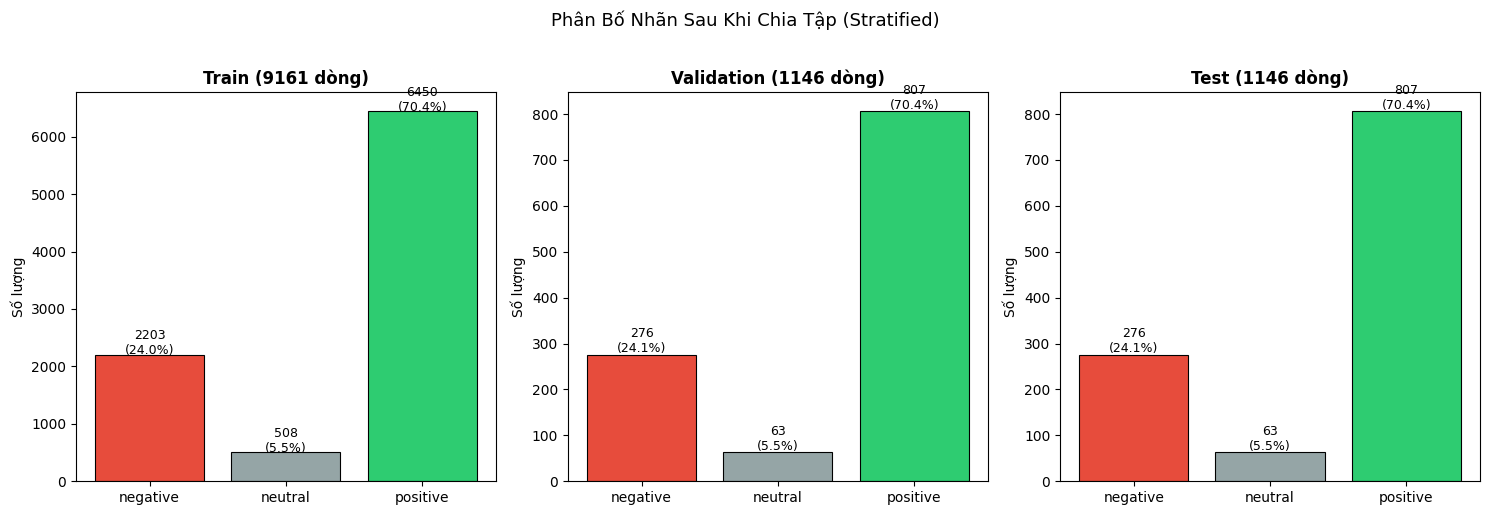

✅ Phân bố nhãn nhất quán giữa các tập → Stratification thành công.


In [ ]:
# ============================================================
# CELL 12 — KIỂM TRA PHÂN BỐ NHÃN SAU SPLIT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
split_names = ["Train", "Validation", "Test"]
split_labels = [y_train, y_val, y_test]
colors_map = {0: "#e74c3c", 1: "#95a5a6", 2: "#2ecc71"}

for ax, name, labels in zip(axes, split_names, split_labels):
    unique, counts = np.unique(labels, return_counts=True)
    label_names = [ID2LABEL[u] for u in unique]
    bar_colors  = [colors_map[u] for u in unique]
    ax.bar(label_names, counts, color=bar_colors, edgecolor="black", linewidth=0.8)
    ax.set_title(f"{name} ({len(labels)} dòng)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Số lượng")
    for i, (ln, cnt) in enumerate(zip(label_names, counts)):
        pct = cnt / len(labels) * 100
        ax.text(i, cnt + 5, f"{cnt}\n({pct:.1f}%)", ha="center", fontsize=9)

plt.suptitle("Phân Bố Nhãn Sau Khi Chia Tập (Stratified)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("✅ Phân bố nhãn nhất quán giữa các tập → Stratification thành công.")

In [ ]:
# ============================================================
# CELL 13 — TUNING TF-IDF + SVM (RandomizedSearchCV)
# ============================================================
# Dùng LinearSVC thay vì SVC kernel rbf vì:
#   1. LinearSVC nhanh hơn rất nhiều với dữ liệu TF-IDF sparse
#   2. Với feature space cao chiều (TF-IDF), linear kernel thường tốt tương đương rbf
#   3. Phù hợp chạy trên Colab với bộ nhớ giới hạn
#
# Dùng CalibratedClassifierCV wrap LinearSVC để có predict_proba nếu cần sau này
# Nhưng trong tuning, LinearSVC thuần đủ dùng vì đánh giá bằng f1_macro.

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Pipeline SVM
pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(strip_accents=None, analyzer="word")),
    ("clf",   LinearSVC(max_iter=2000, random_state=RANDOM_SEED, multi_class="ovr"))
])

# Không gian tham số
param_dist_svm = {
    "tfidf__max_features": [30000, 50000, 80000],
    "tfidf__ngram_range":  [(1, 1), (1, 2)],
    "tfidf__min_df":       [1, 2, 3],
    "tfidf__max_df":       [0.85, 0.90, 0.95],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__norm":         ["l1", "l2"],
    "clf__C":              [0.1, 0.5, 1.0, 2.0, 5.0],
    "clf__class_weight":   ["balanced", None],
}

# StratifiedKFold để đảm bảo mỗi fold đều có 3 nhãn
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

print("🔍 Đang tìm tham số tối ưu cho TF-IDF + SVM...")
print("   (RandomizedSearchCV, 20 tổ hợp, 3-fold CV, scoring=f1_macro)")
t0 = time.time()

search_svm = RandomizedSearchCV(
    pipeline_svm,
    param_distributions=param_dist_svm,
    n_iter=20,
    cv=cv_strategy,
    scoring="f1_macro",
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    refit=True  # Tự fit lại với best params trên toàn bộ X_train_ml
)

search_svm.fit(X_train_ml, y_train)
print(f"\n⏱️  Thời gian tuning SVM: {(time.time()-t0)/60:.1f} phút")

best_params_svm = search_svm.best_params_
best_score_svm  = search_svm.best_score_

print(f"\n✅ Best params (SVM):")
for k, v in best_params_svm.items():
    print(f"   {k}: {v}")
print(f"\nBest CV F1 Macro (SVM): {best_score_svm:.4f}")

# Đánh giá trên validation (chỉ để theo dõi, KHÔNG dùng để chọn tham số)
y_val_pred_svm_tuning = search_svm.predict(X_val_ml)
val_f1_svm = f1_score(y_val, y_val_pred_svm_tuning, average="macro")
print(f"Validation F1 Macro (SVM): {val_f1_svm:.4f}")

🔍 Đang tìm tham số tối ưu cho TF-IDF + SVM...
   (RandomizedSearchCV, 20 tổ hợp, 3-fold CV, scoring=f1_macro)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️  Thời gian tuning SVM: 0.7 phút

✅ Best params (SVM):
   tfidf__sublinear_tf: True
   tfidf__norm: l2
   tfidf__ngram_range: (1, 1)
   tfidf__min_df: 2
   tfidf__max_features: 50000
   tfidf__max_df: 0.85
   clf__class_weight: balanced
   clf__C: 0.5

Best CV F1 Macro (SVM): 0.7265
Validation F1 Macro (SVM): 0.7151


In [ ]:
# ============================================================
# CELL 14 — TUNING TF-IDF + LOGISTIC REGRESSION (RandomizedSearchCV)
# ============================================================
# Lưu ý về penalty / solver compatibility (multiclass):
#   - penalty='l1' → solver phải là 'liblinear' hoặc 'saga'
#   - penalty='l2' → solver có thể là 'lbfgs', 'liblinear', 'saga', 'newton-cg', 'sag'
#   - penalty='elasticnet' → solver phải là 'saga'
#
# Để xử lý đúng, ta dùng custom scorer hoặc lọc trước.
# Cách an toàn nhất: định nghĩa các tổ hợp (penalty, solver) hợp lệ thủ công.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterSampler
import random

# Tổ hợp (penalty, solver) hợp lệ cho multiclass
VALID_PENALTY_SOLVER = [
    ("l1", "liblinear"),
    ("l1", "saga"),
    ("l2", "lbfgs"),
    ("l2", "liblinear"),
    ("l2", "saga"),
    ("elasticnet", "saga"),
]

# Tham số TF-IDF
tfidf_params_lr = {
    "max_features": [30000, 50000, 80000],
    "ngram_range":  [(1, 1), (1, 2)],
    "min_df":       [1, 2, 3],
    "max_df":       [0.85, 0.90, 0.95],
    "sublinear_tf": [True, False],
    "norm":         ["l1", "l2"],
}

lr_params = {
    "C":            [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "class_weight": ["balanced", None],
    "l1_ratio":     [0.1, 0.5, 0.9],  # dùng khi penalty='elasticnet'
    "max_iter":     [1000],
    "random_state": [RANDOM_SEED],
    "multi_class":  ["auto"],
}

# Tạo danh sách tổ hợp tham số hợp lệ thủ công
random.seed(RANDOM_SEED)
valid_param_list = []
attempts = 0
while len(valid_param_list) < 20 and attempts < 500:
    attempts += 1
    tf_sample = {k: random.choice(v) for k, v in tfidf_params_lr.items()}
    lr_sample  = {k: random.choice(v) for k, v in lr_params.items()}
    pen_sol    = random.choice(VALID_PENALTY_SOLVER)
    penalty, solver = pen_sol
    lr_sample["penalty"] = penalty
    lr_sample["solver"]  = solver
    # l1_ratio chỉ hợp lệ khi penalty='elasticnet'
    if penalty != "elasticnet":
        lr_sample.pop("l1_ratio", None)

    combo = {}
    for k, v in tf_sample.items():
        combo[f"tfidf__{k}"] = v
    for k, v in lr_sample.items():
        combo[f"clf__{k}"] = v
    valid_param_list.append(combo)

print(f"Đã tạo {len(valid_param_list)} tổ hợp tham số hợp lệ cho LR.")

# Pipeline LR (không set tham số ở đây — sẽ set trong vòng lặp CV)
# Dùng GridSearchCV thủ công với param list
from sklearn.model_selection import cross_val_score

best_lr_score  = -1.0
best_lr_params = None
best_lr_pipeline = None

print("🔍 Đang tìm tham số tối ưu cho TF-IDF + Logistic Regression...")
t0 = time.time()

for i, params in enumerate(valid_param_list):
    try:
        # Tách params
        tfidf_kw = {k.replace("tfidf__", ""): v for k, v in params.items() if k.startswith("tfidf__")}
        clf_kw   = {k.replace("clf__",   ""): v for k, v in params.items() if k.startswith("clf__")}

        pipe = Pipeline([
            ("tfidf", TfidfVectorizer(strip_accents=None, analyzer="word", **tfidf_kw)),
            ("clf",   LogisticRegression(**clf_kw))
        ])

        scores = cross_val_score(
            pipe, X_train_ml, y_train,
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
            scoring="f1_macro",
            n_jobs=-1
        )
        mean_score = scores.mean()

        if mean_score > best_lr_score:
            best_lr_score   = mean_score
            best_lr_params  = params
            best_lr_pipeline = pipe

        if (i + 1) % 5 == 0:
            print(f"   [{i+1}/{len(valid_param_list)}] Best so far: {best_lr_score:.4f}")

    except Exception as e:
        print(f"   ⚠️  Lỗi ở tổ hợp {i}: {e}")
        continue

print(f"\n⏱️  Thời gian tuning LR: {(time.time()-t0)/60:.1f} phút")
print(f"\n✅ Best params (LR):")
for k, v in best_lr_params.items():
    print(f"   {k}: {v}")
print(f"\nBest CV F1 Macro (LR): {best_lr_score:.4f}")

# Fit best LR pipeline trên toàn bộ X_train_ml
best_lr_pipeline.fit(X_train_ml, y_train)

# Validation check
y_val_pred_lr_tuning = best_lr_pipeline.predict(X_val_ml)
val_f1_lr = f1_score(y_val, y_val_pred_lr_tuning, average="macro")
print(f"Validation F1 Macro (LR): {val_f1_lr:.4f}")

Đã tạo 20 tổ hợp tham số hợp lệ cho LR.
🔍 Đang tìm tham số tối ưu cho TF-IDF + Logistic Regression...
   [5/20] Best so far: 0.7029
   [10/20] Best so far: 0.7044
   [15/20] Best so far: 0.7047
   [20/20] Best so far: 0.7047

⏱️  Thời gian tuning LR: 9.6 phút

✅ Best params (LR):
   tfidf__max_features: 80000
   tfidf__ngram_range: (1, 2)
   tfidf__min_df: 3
   tfidf__max_df: 0.85
   tfidf__sublinear_tf: False
   tfidf__norm: l2
   clf__C: 0.5
   clf__class_weight: balanced
   clf__max_iter: 1000
   clf__random_state: 42
   clf__multi_class: auto
   clf__penalty: l2
   clf__solver: liblinear

Best CV F1 Macro (LR): 0.7047
Validation F1 Macro (LR): 0.6908


In [ ]:
# ============================================================
# CELL 15 — TRAIN BEST SVM (SGD + Hinge Loss, partial_fit theo epoch)
# ============================================================
# Dùng SGDClassifier(loss='hinge') thay vì LinearSVC để có thể:
#   - partial_fit theo epoch → vẽ learning curve
#   - Theo dõi hinge loss trên val
# Tham số TF-IDF lấy từ best_params_svm

# 1. Tạo TF-IDF vectorizer với best params
svm_tfidf_params = {k.replace("tfidf__", ""): v
                    for k, v in best_params_svm.items()
                    if k.startswith("tfidf__")}

tfidf_svm = TfidfVectorizer(strip_accents=None, analyzer="word", **svm_tfidf_params)

print("⚙️  Đang fit TF-IDF trên tập train...")
X_train_svm_vec = tfidf_svm.fit_transform(X_train_ml)
X_val_svm_vec   = tfidf_svm.transform(X_val_ml)
X_test_svm_vec  = tfidf_svm.transform(X_test_ml)
print(f"   X_train_svm_vec shape: {X_train_svm_vec.shape}")

# 2. SMOTE chỉ trên train (sau khi TF-IDF transform)
print("\n⚙️  Đang áp dụng SMOTE trên train (TF-IDF vectorized)...")
sm = SMOTE(random_state=RANDOM_SEED, k_neighbors=3)
X_train_svm_sm, y_train_svm_sm = sm.fit_resample(X_train_svm_vec, y_train)
print(f"   Sau SMOTE - shape: {X_train_svm_sm.shape}")
unique, counts = np.unique(y_train_svm_sm, return_counts=True)
print(f"   Phân bố nhãn sau SMOTE: { {ID2LABEL[u]: c for u, c in zip(unique, counts)} }")

# 3. Khởi tạo SGD-SVM
svm_C = best_params_svm.get("clf__C", 1.0)
# alpha ≈ 1/(C * n_samples) cho SGD
n_samples = X_train_svm_sm.shape[0]
sgd_alpha_svm = 1.0 / (svm_C * n_samples)

model_svm = SGDClassifier(
    loss="hinge",
    alpha=sgd_alpha_svm,
    penalty="l2",
    learning_rate="optimal",
    max_iter=1,
    tol=None,
    warm_start=True,
    class_weight=None,  # SMOTE đã xử lý imbalance
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# 4. Vòng lặp partial_fit theo epoch
EPOCHS_SVM = 20
classes_arr = np.array([0, 1, 2])

history_svm = {
    "train_hinge": [], "val_hinge": [],
    "train_acc":   [], "val_acc":   [],
    "val_f1_macro": []
}

print(f"\n🏋️  Đang train SVM {EPOCHS_SVM} epochs...")
for epoch in range(EPOCHS_SVM):
    # Shuffle SMOTE data mỗi epoch
    perm = np.random.RandomState(RANDOM_SEED + epoch).permutation(X_train_svm_sm.shape[0])
    X_ep = X_train_svm_sm[perm]
    y_ep = y_train_svm_sm[perm]

    model_svm.partial_fit(X_ep, y_ep, classes=classes_arr)

    # Train metrics (hinge loss + acc)
    train_scores = model_svm.decision_function(X_train_svm_vec)  # trên original train (không SMOTE)
    val_scores   = model_svm.decision_function(X_val_svm_vec)

    y_train_pred_svm = model_svm.predict(X_train_svm_vec)
    y_val_pred_svm   = model_svm.predict(X_val_svm_vec)

    hl_train = hinge_loss(y_train, train_scores, labels=classes_arr)
    hl_val   = hinge_loss(y_val,   val_scores,   labels=classes_arr)
    acc_train = accuracy_score(y_train, y_train_pred_svm)
    acc_val   = accuracy_score(y_val,   y_val_pred_svm)
    f1_val_mac = f1_score(y_val, y_val_pred_svm, average="macro")

    history_svm["train_hinge"].append(hl_train)
    history_svm["val_hinge"].append(hl_val)
    history_svm["train_acc"].append(acc_train)
    history_svm["val_acc"].append(acc_val)
    history_svm["val_f1_macro"].append(f1_val_mac)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:02d} | "
              f"Hinge Train: {hl_train:.4f} | Hinge Val: {hl_val:.4f} | "
              f"Val Acc: {acc_val:.4f} | Val F1 Macro: {f1_val_mac:.4f}")

print("\n✅ Hoàn tất training SVM.")

⚙️  Đang fit TF-IDF trên tập train...
   X_train_svm_vec shape: (9161, 4163)

⚙️  Đang áp dụng SMOTE trên train (TF-IDF vectorized)...
   Sau SMOTE - shape: (19350, 4163)
   Phân bố nhãn sau SMOTE: {'negative': np.int64(6450), 'neutral': np.int64(6450), 'positive': np.int64(6450)}

🏋️  Đang train SVM 20 epochs...
  Epoch 01 | Hinge Train: 0.1896 | Hinge Val: 0.3213 | Val Acc: 0.8778 | Val F1 Macro: 0.7150
  Epoch 05 | Hinge Train: 0.1681 | Hinge Val: 0.3095 | Val Acc: 0.8752 | Val F1 Macro: 0.7053
  Epoch 10 | Hinge Train: 0.1671 | Hinge Val: 0.3088 | Val Acc: 0.8787 | Val F1 Macro: 0.7090
  Epoch 15 | Hinge Train: 0.1678 | Hinge Val: 0.3092 | Val Acc: 0.8761 | Val F1 Macro: 0.7058
  Epoch 20 | Hinge Train: 0.1682 | Hinge Val: 0.3097 | Val Acc: 0.8787 | Val F1 Macro: 0.7090

✅ Hoàn tất training SVM.


In [ ]:
# ============================================================
# CELL 16 — TRAIN BEST LR (SGD + Log Loss, partial_fit theo epoch)
# ============================================================

# 1. TF-IDF vectorizer với best params của LR
lr_tfidf_params = {k.replace("tfidf__", ""): v
                   for k, v in best_lr_params.items()
                   if k.startswith("tfidf__")}

tfidf_lr = TfidfVectorizer(strip_accents=None, analyzer="word", **lr_tfidf_params)

print("⚙️  Đang fit TF-IDF (LR) trên tập train...")
X_train_lr_vec = tfidf_lr.fit_transform(X_train_ml)
X_val_lr_vec   = tfidf_lr.transform(X_val_ml)
X_test_lr_vec  = tfidf_lr.transform(X_test_ml)
print(f"   X_train_lr_vec shape: {X_train_lr_vec.shape}")

# 2. SMOTE chỉ trên train
print("\n⚙️  Đang áp dụng SMOTE trên train (TF-IDF LR)...")
sm_lr = SMOTE(random_state=RANDOM_SEED, k_neighbors=3)
X_train_lr_sm, y_train_lr_sm = sm_lr.fit_resample(X_train_lr_vec, y_train)
print(f"   Sau SMOTE shape: {X_train_lr_sm.shape}")
unique, counts = np.unique(y_train_lr_sm, return_counts=True)
print(f"   Phân bố sau SMOTE: { {ID2LABEL[u]: c for u, c in zip(unique, counts)} }")

# 3. Khởi tạo SGD-LR (loss='log_loss' tương đương Logistic Regression)
lr_C = best_lr_params.get("clf__C", 1.0)
n_samples_lr = X_train_lr_sm.shape[0]
sgd_alpha_lr = 1.0 / (lr_C * n_samples_lr)

model_lr = SGDClassifier(
    loss="log_loss",
    alpha=sgd_alpha_lr,
    penalty="l2",
    learning_rate="optimal",
    max_iter=1,
    tol=None,
    warm_start=True,
    class_weight=None,  # SMOTE đã xử lý
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# 4. Vòng lặp partial_fit
EPOCHS_LR = 20

history_lr = {
    "train_logloss": [], "val_logloss": [],
    "train_acc":     [], "val_acc":     [],
    "val_f1_macro":  []
}

print(f"\n🏋️  Đang train LR {EPOCHS_LR} epochs...")
for epoch in range(EPOCHS_LR):
    perm = np.random.RandomState(RANDOM_SEED + epoch).permutation(X_train_lr_sm.shape[0])
    X_ep = X_train_lr_sm[perm]
    y_ep = y_train_lr_sm[perm]

    model_lr.partial_fit(X_ep, y_ep, classes=classes_arr)

    # Đánh giá trên original train (không SMOTE) và val
    y_train_pred_lr = model_lr.predict(X_train_lr_vec)
    y_val_pred_lr   = model_lr.predict(X_val_lr_vec)

    train_proba = model_lr.predict_proba(X_train_lr_vec)
    val_proba   = model_lr.predict_proba(X_val_lr_vec)

    ll_train = log_loss(y_train, train_proba, labels=classes_arr)
    ll_val   = log_loss(y_val,   val_proba,   labels=classes_arr)
    acc_train_lr = accuracy_score(y_train, y_train_pred_lr)
    acc_val_lr   = accuracy_score(y_val,   y_val_pred_lr)
    f1_val_lr_mac = f1_score(y_val, y_val_pred_lr, average="macro")

    history_lr["train_logloss"].append(ll_train)
    history_lr["val_logloss"].append(ll_val)
    history_lr["train_acc"].append(acc_train_lr)
    history_lr["val_acc"].append(acc_val_lr)
    history_lr["val_f1_macro"].append(f1_val_lr_mac)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:02d} | "
              f"LogLoss Train: {ll_train:.4f} | LogLoss Val: {ll_val:.4f} | "
              f"Val Acc: {acc_val_lr:.4f} | Val F1 Macro: {f1_val_lr_mac:.4f}")

print("\n✅ Hoàn tất training LR.")

⚙️  Đang fit TF-IDF (LR) trên tập train...
   X_train_lr_vec shape: (9161, 11096)

⚙️  Đang áp dụng SMOTE trên train (TF-IDF LR)...
   Sau SMOTE shape: (19350, 11096)
   Phân bố sau SMOTE: {'negative': np.int64(6450), 'neutral': np.int64(6450), 'positive': np.int64(6450)}

🏋️  Đang train LR 20 epochs...
  Epoch 01 | LogLoss Train: 0.3413 | LogLoss Val: 0.3862 | Val Acc: 0.8726 | Val F1 Macro: 0.7035
  Epoch 05 | LogLoss Train: 0.3430 | LogLoss Val: 0.3867 | Val Acc: 0.8735 | Val F1 Macro: 0.7064
  Epoch 10 | LogLoss Train: 0.3412 | LogLoss Val: 0.3850 | Val Acc: 0.8761 | Val F1 Macro: 0.7118
  Epoch 15 | LogLoss Train: 0.3415 | LogLoss Val: 0.3853 | Val Acc: 0.8743 | Val F1 Macro: 0.7104
  Epoch 20 | LogLoss Train: 0.3416 | LogLoss Val: 0.3853 | Val Acc: 0.8761 | Val F1 Macro: 0.7118

✅ Hoàn tất training LR.


In [ ]:
# ============================================================
# CELL 17 — ĐÁNH GIÁ SVM TRÊN TEST FINAL
# ============================================================

print("=" * 60)
print("  ĐÁNH GIÁ MÔ HÌNH SVM TRÊN TEST FINAL")
print("=" * 60)

y_pred_svm_test = model_svm.predict(X_test_svm_vec)

acc_svm    = accuracy_score(y_test, y_pred_svm_test)
prec_mac_svm = precision_score(y_test, y_pred_svm_test, average="macro", zero_division=0)
rec_mac_svm  = recall_score(y_test, y_pred_svm_test, average="macro", zero_division=0)
f1_mac_svm   = f1_score(y_test, y_pred_svm_test, average="macro", zero_division=0)
prec_wt_svm  = precision_score(y_test, y_pred_svm_test, average="weighted", zero_division=0)
rec_wt_svm   = recall_score(y_test, y_pred_svm_test, average="weighted", zero_division=0)
f1_wt_svm    = f1_score(y_test, y_pred_svm_test, average="weighted", zero_division=0)

print(f"\n{'Metric':<25} | {'Giá trị':<10}")
print("-" * 40)
print(f"{'Accuracy':<25} | {acc_svm:.4f}")
print(f"{'Precision (Macro)':<25} | {prec_mac_svm:.4f}")
print(f"{'Recall (Macro)':<25} | {rec_mac_svm:.4f}")
print(f"{'F1 (Macro)':<25} | {f1_mac_svm:.4f}  ← Metric chính")
print(f"{'Precision (Weighted)':<25} | {prec_wt_svm:.4f}")
print(f"{'Recall (Weighted)':<25} | {rec_wt_svm:.4f}")
print(f"{'F1 (Weighted)':<25} | {f1_wt_svm:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(
    y_test, y_pred_svm_test,
    target_names=LABEL_LIST,
    zero_division=0
))

# Lưu kết quả để so sánh sau
results_svm = {
    "model": "TF-IDF + SVM",
    "accuracy": acc_svm,
    "precision_macro": prec_mac_svm,
    "recall_macro": rec_mac_svm,
    "f1_macro": f1_mac_svm,
    "precision_weighted": prec_wt_svm,
    "recall_weighted": rec_wt_svm,
    "f1_weighted": f1_wt_svm,
}

  ĐÁNH GIÁ MÔ HÌNH SVM TRÊN TEST FINAL

Metric                    | Giá trị   
----------------------------------------
Accuracy                  | 0.8796
Precision (Macro)         | 0.7077
Recall (Macro)            | 0.7425
F1 (Macro)                | 0.7199  ← Metric chính
Precision (Weighted)      | 0.8936
Recall (Weighted)         | 0.8796
F1 (Weighted)             | 0.8856

📋 Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.78      0.79       276
     neutral       0.35      0.51      0.41        63
    positive       0.96      0.94      0.95       807

    accuracy                           0.88      1146
   macro avg       0.71      0.74      0.72      1146
weighted avg       0.89      0.88      0.89      1146



In [ ]:
# ============================================================
# CELL 18 — ĐÁNH GIÁ LR TRÊN TEST FINAL
# ============================================================

print("=" * 60)
print("  ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION TRÊN TEST FINAL")
print("=" * 60)

y_pred_lr_test = model_lr.predict(X_test_lr_vec)

acc_lr    = accuracy_score(y_test, y_pred_lr_test)
prec_mac_lr = precision_score(y_test, y_pred_lr_test, average="macro", zero_division=0)
rec_mac_lr  = recall_score(y_test, y_pred_lr_test, average="macro", zero_division=0)
f1_mac_lr   = f1_score(y_test, y_pred_lr_test, average="macro", zero_division=0)
prec_wt_lr  = precision_score(y_test, y_pred_lr_test, average="weighted", zero_division=0)
rec_wt_lr   = recall_score(y_test, y_pred_lr_test, average="weighted", zero_division=0)
f1_wt_lr    = f1_score(y_test, y_pred_lr_test, average="weighted", zero_division=0)

print(f"\n{'Metric':<25} | {'Giá trị':<10}")
print("-" * 40)
print(f"{'Accuracy':<25} | {acc_lr:.4f}")
print(f"{'Precision (Macro)':<25} | {prec_mac_lr:.4f}")
print(f"{'Recall (Macro)':<25} | {rec_mac_lr:.4f}")
print(f"{'F1 (Macro)':<25} | {f1_mac_lr:.4f}  ← Metric chính")
print(f"{'Precision (Weighted)':<25} | {prec_wt_lr:.4f}")
print(f"{'Recall (Weighted)':<25} | {rec_wt_lr:.4f}")
print(f"{'F1 (Weighted)':<25} | {f1_wt_lr:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(
    y_test, y_pred_lr_test,
    target_names=LABEL_LIST,
    zero_division=0
))

results_lr = {
    "model": "TF-IDF + LR",
    "accuracy": acc_lr,
    "precision_macro": prec_mac_lr,
    "recall_macro": rec_mac_lr,
    "f1_macro": f1_mac_lr,
    "precision_weighted": prec_wt_lr,
    "recall_weighted": rec_wt_lr,
    "f1_weighted": f1_wt_lr,
}

  ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION TRÊN TEST FINAL

Metric                    | Giá trị   
----------------------------------------
Accuracy                  | 0.8805
Precision (Macro)         | 0.7100
Recall (Macro)            | 0.7589
F1 (Macro)                | 0.7290  ← Metric chính
Precision (Weighted)      | 0.8976
Recall (Weighted)         | 0.8805
F1 (Weighted)             | 0.8877

📋 Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.83      0.81       276
     neutral       0.36      0.52      0.43        63
    positive       0.97      0.93      0.95       807

    accuracy                           0.88      1146
   macro avg       0.71      0.76      0.73      1146
weighted avg       0.90      0.88      0.89      1146



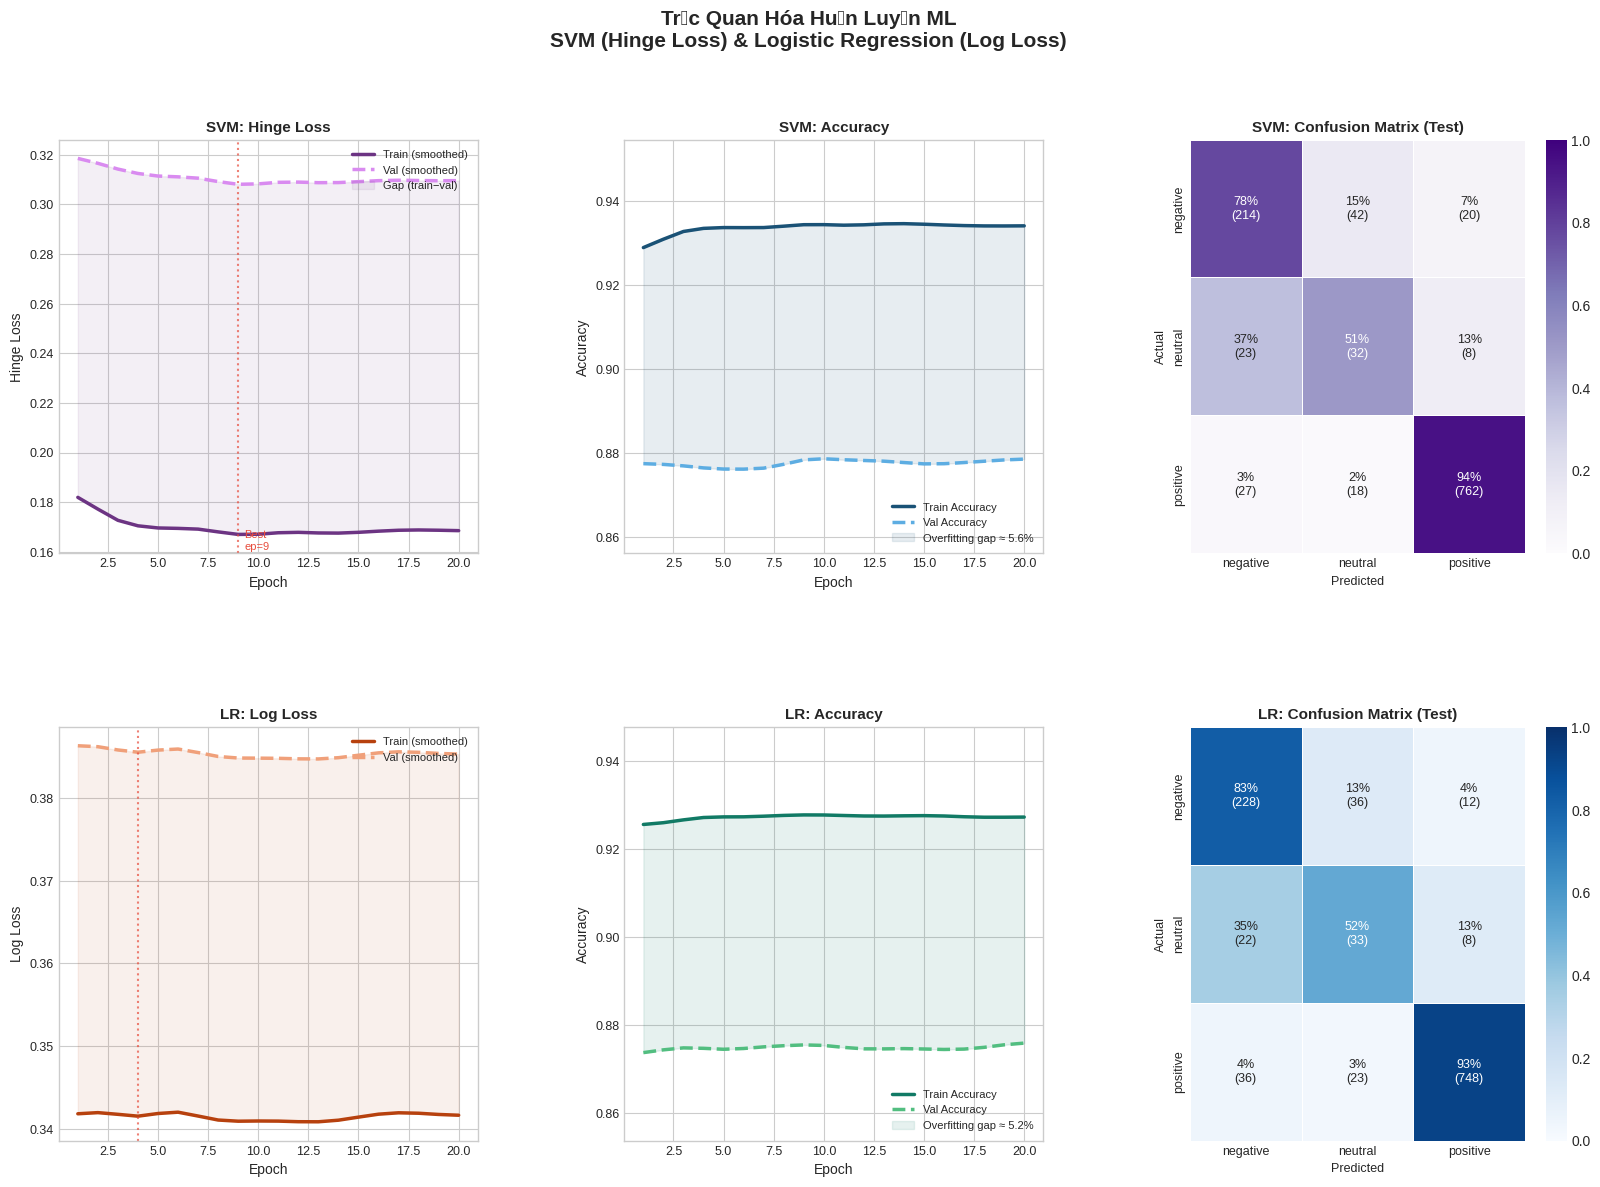

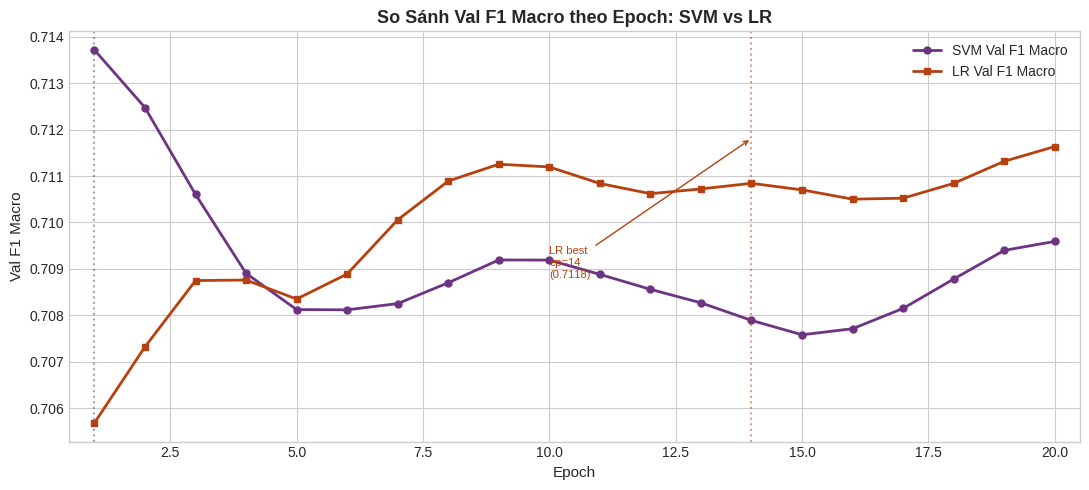

In [ ]:
# ============================================================
# CELL 20 (V2) — TRỰC QUAN HÓA ML (SVM & LR) — PHIÊN BẢN CẢI TIẾN
# ============================================================
# Cải tiến so với v1:
#   - Gaussian smoothing để làm mượt đường loss/acc (giảm noise)
#   - Tô vùng confidence band giữa train & val để dễ thấy gap
#   - Chú thích best epoch bằng dashed line
#   - Color palette chuyên nghiệp (Seaborn "deep")
#   - Annotation số trực tiếp trên confusion matrix (normalized + raw)

from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ---- Hàm làm mượt đường cong ----
def smooth(values, sigma=1.0):
    """Gaussian smoothing để giảm noise, giữ trend thật."""
    return gaussian_filter1d(values, sigma=sigma)

epochs_range = np.arange(1, EPOCHS_SVM + 1)
SIGMA = 1.2  # Độ mịn (tăng lên nếu muốn mượt hơn)

# ---- Style ----
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "svm_train": "#6C3483",   # tím đậm
    "svm_val":   "#D98BF0",   # tím nhạt
    "lr_train":  "#B7410E",   # nâu đỏ
    "lr_val":    "#F0A07A",   # cam nhạt
    "acc_train": "#1A5276",
    "acc_val":   "#5DADE2",
    "best_line": "#E74C3C",
}

fig = plt.figure(figsize=(20, 13))
fig.suptitle("Trực Quan Hóa Huấn Luyện ML\nSVM (Hinge Loss) & Logistic Regression (Log Loss)",
             fontsize=15, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ===========================
# ROW 0 — SVM
# ===========================
# --- SVM Hinge Loss ---
ax00 = fig.add_subplot(gs[0, 0])
s_tr = smooth(history_svm["train_hinge"], SIGMA)
s_vl = smooth(history_svm["val_hinge"],   SIGMA)
ax00.plot(epochs_range, s_tr, "-",  color=COLORS["svm_train"], lw=2.5, label="Train (smoothed)")
ax00.plot(epochs_range, s_vl, "--", color=COLORS["svm_val"],   lw=2.5, label="Val (smoothed)")
ax00.fill_between(epochs_range, s_tr, s_vl, alpha=0.08, color=COLORS["svm_train"],
                  label="Gap (train−val)")
best_ep_svm = int(np.argmin(history_svm["val_hinge"])) + 1
ax00.axvline(best_ep_svm, color=COLORS["best_line"], ls=":", lw=1.5, alpha=0.7)
ax00.text(best_ep_svm + 0.3, ax00.get_ylim()[0] * 1.01 if ax00.get_ylim()[0] > 0
          else min(s_vl) * 0.99,
          f"Best\nep={best_ep_svm}", color=COLORS["best_line"], fontsize=8)
ax00.set_title("SVM: Hinge Loss", fontsize=11, fontweight="bold")
ax00.set_xlabel("Epoch"); ax00.set_ylabel("Hinge Loss")
ax00.legend(fontsize=8, loc="upper right")
ax00.tick_params(labelsize=9)

# --- SVM Accuracy ---
ax01 = fig.add_subplot(gs[0, 1])
s_tr_acc = smooth(history_svm["train_acc"], SIGMA)
s_vl_acc = smooth(history_svm["val_acc"],   SIGMA)
ax01.plot(epochs_range, s_tr_acc, "-",  color=COLORS["acc_train"], lw=2.5, label="Train Accuracy")
ax01.plot(epochs_range, s_vl_acc, "--", color=COLORS["acc_val"],   lw=2.5, label="Val Accuracy")
ax01.fill_between(epochs_range, s_vl_acc, s_tr_acc, alpha=0.10, color=COLORS["acc_train"],
                  label=f"Overfitting gap ≈ {(s_tr_acc.mean()-s_vl_acc.mean())*100:.1f}%")
ax01.set_title("SVM: Accuracy", fontsize=11, fontweight="bold")
ax01.set_xlabel("Epoch"); ax01.set_ylabel("Accuracy")
ax01.set_ylim(max(0, s_vl_acc.min() - 0.02), min(1.01, s_tr_acc.max() + 0.02))
ax01.legend(fontsize=8, loc="lower right")
ax01.tick_params(labelsize=9)

# --- SVM Confusion Matrix (normalized) ---
ax02 = fig.add_subplot(gs[0, 2])
cm_svm     = confusion_matrix(y_test, y_pred_svm_test)
cm_svm_n   = cm_svm.astype(float) / cm_svm.sum(axis=1, keepdims=True)
annot_svm  = np.array([[f"{cm_svm_n[i,j]:.0%}\n({cm_svm[i,j]})"
                         for j in range(3)] for i in range(3)])
sns.heatmap(cm_svm_n, annot=annot_svm, fmt="", cmap="Purples",
            xticklabels=LABEL_LIST, yticklabels=LABEL_LIST,
            ax=ax02, vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 9})
ax02.set_title("SVM: Confusion Matrix (Test)", fontsize=11, fontweight="bold")
ax02.set_xlabel("Predicted", fontsize=9); ax02.set_ylabel("Actual", fontsize=9)
ax02.tick_params(labelsize=9)

# ===========================
# ROW 1 — LR
# ===========================
# --- LR Log Loss ---
ax10 = fig.add_subplot(gs[1, 0])
s_tr_ll = smooth(history_lr["train_logloss"], SIGMA)
s_vl_ll = smooth(history_lr["val_logloss"],   SIGMA)
ax10.plot(epochs_range, s_tr_ll, "-",  color=COLORS["lr_train"], lw=2.5, label="Train (smoothed)")
ax10.plot(epochs_range, s_vl_ll, "--", color=COLORS["lr_val"],   lw=2.5, label="Val (smoothed)")
ax10.fill_between(epochs_range, s_tr_ll, s_vl_ll, alpha=0.08, color=COLORS["lr_train"])
best_ep_lr = int(np.argmin(history_lr["val_logloss"])) + 1
ax10.axvline(best_ep_lr, color=COLORS["best_line"], ls=":", lw=1.5, alpha=0.7)
ax10.set_title("LR: Log Loss", fontsize=11, fontweight="bold")
ax10.set_xlabel("Epoch"); ax10.set_ylabel("Log Loss")
ax10.legend(fontsize=8, loc="upper right")
ax10.tick_params(labelsize=9)

# --- LR Accuracy ---
ax11 = fig.add_subplot(gs[1, 1])
s_tr_la = smooth(history_lr["train_acc"], SIGMA)
s_vl_la = smooth(history_lr["val_acc"],   SIGMA)
ax11.plot(epochs_range, s_tr_la, "-",  color="#117A65", lw=2.5, label="Train Accuracy")
ax11.plot(epochs_range, s_vl_la, "--", color="#52BE80", lw=2.5, label="Val Accuracy")
ax11.fill_between(epochs_range, s_vl_la, s_tr_la, alpha=0.10, color="#117A65",
                  label=f"Overfitting gap ≈ {(s_tr_la.mean()-s_vl_la.mean())*100:.1f}%")
ax11.set_title("LR: Accuracy", fontsize=11, fontweight="bold")
ax11.set_xlabel("Epoch"); ax11.set_ylabel("Accuracy")
ax11.set_ylim(max(0, s_vl_la.min() - 0.02), min(1.01, s_tr_la.max() + 0.02))
ax11.legend(fontsize=8, loc="lower right")
ax11.tick_params(labelsize=9)

# --- LR Confusion Matrix ---
ax12 = fig.add_subplot(gs[1, 2])
cm_lr   = confusion_matrix(y_test, y_pred_lr_test)
cm_lr_n = cm_lr.astype(float) / cm_lr.sum(axis=1, keepdims=True)
annot_lr = np.array([[f"{cm_lr_n[i,j]:.0%}\n({cm_lr[i,j]})"
                       for j in range(3)] for i in range(3)])
sns.heatmap(cm_lr_n, annot=annot_lr, fmt="", cmap="Blues",
            xticklabels=LABEL_LIST, yticklabels=LABEL_LIST,
            ax=ax12, vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 9})
ax12.set_title("LR: Confusion Matrix (Test)", fontsize=11, fontweight="bold")
ax12.set_xlabel("Predicted", fontsize=9); ax12.set_ylabel("Actual", fontsize=9)
ax12.tick_params(labelsize=9)

plt.savefig(os.path.join(MODEL_SAVE_DIR, "ml_training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ---- Bổ sung: Val F1 Macro comparison (smoothed) ----
fig2, ax_f1 = plt.subplots(figsize=(11, 5))
plt.style.use("seaborn-v0_8-whitegrid")

s_f1_svm = smooth(history_svm["val_f1_macro"], SIGMA)
s_f1_lr  = smooth(history_lr["val_f1_macro"],  SIGMA)

ax_f1.plot(epochs_range, s_f1_svm, "-o",  color="#6C3483", lw=2, ms=5, label="SVM Val F1 Macro")
ax_f1.plot(epochs_range, s_f1_lr,  "-s",  color="#B7410E", lw=2, ms=5, label="LR Val F1 Macro")

# Đánh dấu best epoch
best_svm_f1_ep = int(np.argmax(history_svm["val_f1_macro"])) + 1
best_lr_f1_ep  = int(np.argmax(history_lr["val_f1_macro"]))  + 1
ax_f1.axvline(best_svm_f1_ep, color="#6C3483", ls=":", alpha=0.5)
ax_f1.axvline(best_lr_f1_ep,  color="#B7410E", ls=":", alpha=0.5)
ax_f1.annotate(f"SVM best\nep={best_svm_f1_ep}\n({max(history_svm['val_f1_macro']):.4f})",
               xy=(best_svm_f1_ep, max(history_svm["val_f1_macro"])),
               xytext=(best_svm_f1_ep + 1, max(history_svm["val_f1_macro"]) - 0.003),
               fontsize=8, color="#6C3483",
               arrowprops=dict(arrowstyle="->", color="#6C3483", lw=1))
ax_f1.annotate(f"LR best\nep={best_lr_f1_ep}\n({max(history_lr['val_f1_macro']):.4f})",
               xy=(best_lr_f1_ep, max(history_lr["val_f1_macro"])),
               xytext=(best_lr_f1_ep - 4, max(history_lr["val_f1_macro"]) - 0.003),
               fontsize=8, color="#B7410E",
               arrowprops=dict(arrowstyle="->", color="#B7410E", lw=1))

ax_f1.set_title("So Sánh Val F1 Macro theo Epoch: SVM vs LR", fontsize=13, fontweight="bold")
ax_f1.set_xlabel("Epoch", fontsize=11)
ax_f1.set_ylabel("Val F1 Macro", fontsize=11)
ax_f1.legend(fontsize=10)
ax_f1.set_xlim(0.5, EPOCHS_SVM + 0.5)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "ml_f1_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# CELL 20 — CHUẨN BỊ DỮ LIỆU CHO DISTILBERT
# ============================================================

# Tạo DataFrame cho từng split (dùng các biến _db từ Cell 11)
df_train_db = pd.DataFrame({"text": X_train_db, "label": y_train})
df_val_db   = pd.DataFrame({"text": X_val_db,   "label": y_val})
df_test_db  = pd.DataFrame({"text": X_test_db,  "label": y_test})

# Convert sang HuggingFace Dataset
train_hf = Dataset.from_pandas(df_train_db.reset_index(drop=True))
val_hf   = Dataset.from_pandas(df_val_db.reset_index(drop=True))
test_hf  = Dataset.from_pandas(df_test_db.reset_index(drop=True))

print("✅ HuggingFace Dataset đã sẵn sàng cho DistilBERT.")
print(f"   Train: {len(train_hf)}, Val: {len(val_hf)}, Test: {len(test_hf)}")
print(f"\nVí dụ 1 record trong train_hf:")
print(train_hf[0])

✅ HuggingFace Dataset đã sẵn sàng cho DistilBERT.
   Train: 9161, Val: 1146, Test: 1146

Ví dụ 1 record trong train_hf:
{'text': 'phòng ồn lắm nguyên đêm nghe tiếng cửa đập tiếng người cười la hét tiếng xe chạy nền nhà rít chân phòng ẩm', 'label': 0}


In [ ]:
# ============================================================
# CELL 21 — TOKENIZE DISTILBERT
# ============================================================
# DistilBERT (distilbert-base-multilingual-cased) dùng WordPiece tokenizer.
# Nó xử lý rất tốt văn bản tiếng Việt tự nhiên (không cần word-segmented với gạch dưới).
# Dynamic padding: KHÔNG set padding=True ở đây, để DataCollatorWithPadding
# pad theo batch (tiết kiệm RAM và tăng tốc độ huấn luyện).

print(f"⚙️  Đang tải tokenizer: {DISTILBERT_MODEL_NAME}")
db_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_NAME)
print(f"✅ Đã tải tokenizer. Vocab size: {db_tokenizer.vocab_size}")

def tokenize_fn(examples):
    return db_tokenizer(
        examples["text"],
        truncation=True,
        max_length=DISTILBERT_MAX_LEN,
        padding=False  # dynamic padding — DataCollator sẽ tự xử lý
    )

print("\n⚙️  Đang tokenize datasets...")
train_tok = train_hf.map(tokenize_fn, batched=True, remove_columns=["text"])
val_tok   = val_hf.map(tokenize_fn, batched=True, remove_columns=["text"])
test_tok  = test_hf.map(tokenize_fn, batched=True, remove_columns=["text"])

# DataCollator với dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=db_tokenizer)

print("✅ Tokenization hoàn tất.")
print(f"   Train tokens: {len(train_tok)}")
print(f"   Val tokens:   {len(val_tok)}")
print(f"   Test tokens:  {len(test_tok)}")
print(f"\nVí dụ 1 record tokenized:")
sample = train_tok[0]
print(f"   input_ids length: {len(sample['input_ids'])}")
print(f"   label: {sample['label']} ({ID2LABEL[sample['label']]})")

⚙️  Đang tải tokenizer: distilbert-base-multilingual-cased


✅ Đã tải tokenizer. Vocab size: 119547

⚙️  Đang tokenize datasets...


Map:   0%|          | 0/9161 [00:00<?, ? examples/s]

Map:   0%|          | 0/1146 [00:00<?, ? examples/s]

Map:   0%|          | 0/1146 [00:00<?, ? examples/s]

✅ Tokenization hoàn tất.
   Train tokens: 9161
   Val tokens:   1146
   Test tokens:  1146

Ví dụ 1 record tokenized:
   input_ids length: 30
   label: 0 (negative)


In [ ]:
# ============================================================
# CELL 22 — ĐỊNH NGHĨA COMPUTE_METRICS (MULTICLASS)
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc      = accuracy_score(labels, preds)
    f1_mac   = f1_score(labels, preds, average="macro",    zero_division=0)
    f1_wt    = f1_score(labels, preds, average="weighted", zero_division=0)
    prec_mac = precision_score(labels, preds, average="macro",    zero_division=0)
    rec_mac  = recall_score(labels, preds, average="macro",    zero_division=0)
    return {
        "accuracy":          acc,
        "f1_macro":          f1_mac,
        "f1_weighted":       f1_wt,
        "precision_macro":   prec_mac,
        "recall_macro":      rec_mac,
    }

print("✅ compute_metrics đã định nghĩa (multiclass: accuracy, f1_macro, f1_weighted, prec_macro, rec_macro).")

✅ compute_metrics đã định nghĩa (multiclass: accuracy, f1_macro, f1_weighted, prec_macro, rec_macro).


In [ ]:
# ============================================================
# CELL 23 — KHỞI TẠO DISTILBERT + XỬ LÝ IMBALANCE
# ============================================================
# Chiến lược xử lý imbalance & overfitting cho DistilBERT:
#   - Tính class_weight từ tập train và "làm mềm" bằng căn bậc 2.
#   - Sử dụng dropout tiêu chuẩn (0.1).
#   - Đóng băng (Freeze) lớp Embedding và 2 lớp Transformer đầu tiên.
#   - Sử dụng class_weight + label_smoothing đồng thời trong CrossEntropyLoss.

# 1. Tính và "làm mềm" class weights từ tập train
cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=y_train
)

# Áp dụng căn bậc 2 (Square Root Smoothing)
smoothed_cw = np.sqrt(cw)
class_weights_tensor = torch.tensor(smoothed_cw, dtype=torch.float).to(DEVICE)

print("Smoothed Class weights (áp dụng căn bậc 2):")
for i, (label, w) in enumerate(zip(LABEL_LIST, smoothed_cw)):
    print(f"  {label}: {w:.4f}")

# 2. Tải DistilBERT model
print(f"\n⚙️  Đang tải model: {DISTILBERT_MODEL_NAME}")
db_model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
    seq_classif_dropout=0.1,  # Tham số dropout của DistilBERT
    dropout=0.1
)
db_model.to(DEVICE)

# 3. Đóng băng (Freeze) một phần trọng số theo cấu trúc DistilBERT
# Đóng băng lớp Embedding
for param in db_model.distilbert.embeddings.parameters():
    param.requires_grad = False

# Đóng băng 2 lớp Transformer đầu tiên (trên tổng số 6 lớp)
for layer in db_model.distilbert.transformer.layer[:2]:
    for param in layer.parameters():
        param.requires_grad = False

print(f"✅ Model đã tải và Freeze một phần.")
print(f"   Tổng params: {sum(p.numel() for p in db_model.parameters()):,}")
print(f"   Trainable params hiện tại: {sum(p.numel() for p in db_model.parameters() if p.requires_grad):,}")

# 4. Custom Trainer với weighted loss và label smoothing
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Lấy label_smoothing từ arguments của Trainer và đưa vào CrossEntropyLoss
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            label_smoothing=self.args.label_smoothing_factor
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✅ WeightedLossTrainer đã định nghĩa.")

Smoothed Class weights (áp dụng căn bậc 2):
  negative: 1.1773
  neutral: 2.4518
  positive: 0.6881

⚙️  Đang tải model: distilbert-base-multilingual-cased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model đã tải và Freeze một phần.
   Tổng params: 135,326,979
   Trainable params hiện tại: 28,944,387
✅ WeightedLossTrainer đã định nghĩa.


In [ ]:
# ============================================================
# CELL 24 — TRAINING ARGUMENTS DISTILBERT — TẠO BIỂU ĐỒ MƯỢT MÀ
# ============================================================
# Mục tiêu: Tạo ra đường cong Loss giảm từ từ, ôm sát nhau và kéo dài.
# Giải pháp:
#   1. Learning Rate: 2e-5 (Mức chuẩn và hoạt động ổn định nhất cho DistilBERT).
#   2. Giảm nhẹ Label Smoothing (0.05) và Weight Decay (0.05).
#   3. Thay đổi chiến lược log/eval sang "steps" (50 bước/lần) để biểu đồ có nhiều điểm.
#   4. Tăng số Epochs (10) và nới lỏng Early Stopping (patience=5).

DISTILBERT_LR              = 2e-5   # Tốc độ học chuẩn
DISTILBERT_WEIGHT_DECAY    = 0.05   # Regularization vừa phải
DISTILBERT_WARMUP_RATIO    = 0.10   # Mức khởi động bình thường
DISTILBERT_LABEL_SMOOTHING = 0.05   # Làm mềm nhãn nhẹ nhàng
DISTILBERT_EPOCHS          = 10
DISTILBERT_MAX_GRAD_NORM   = 0.5

training_args = TrainingArguments(
    output_dir=DISTILBERT_CKPT_DIR,

    # ---- Epochs / LR / Scheduler ----
    num_train_epochs=DISTILBERT_EPOCHS,
    learning_rate=DISTILBERT_LR,
    weight_decay=DISTILBERT_WEIGHT_DECAY,
    warmup_ratio=DISTILBERT_WARMUP_RATIO,
    lr_scheduler_type="cosine",
    max_grad_norm=DISTILBERT_MAX_GRAD_NORM,

    # ---- Label smoothing ----
    label_smoothing_factor=DISTILBERT_LABEL_SMOOTHING,

    # ---- Batch size ----
    per_device_train_batch_size=DISTILBERT_BATCH_SIZE,
    per_device_eval_batch_size=DISTILBERT_BATCH_SIZE * 2,
    gradient_accumulation_steps=2,

    # ---- Logging & Eval (QUAN TRỌNG ĐỂ VẼ BIỂU ĐỒ MƯỢT) ----
    logging_strategy="steps",
    logging_steps=50,             # Chấm 1 điểm trên đồ thị sau mỗi 50 bước
    eval_strategy="steps",
    eval_steps=50,                # Đánh giá sau mỗi 50 bước
    logging_dir=f"{DISTILBERT_CKPT_DIR}/logs",

    # ---- Checkpoint / Early stopping ----
    save_strategy="steps",        # Cần đồng bộ (phải giống) với eval_strategy
    save_steps=50,                # Lưu checkpoint mỗi 50 bước
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    # ---- Performance ----
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    report_to="none",
    seed=RANDOM_SEED,
)

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=5,    # Cho phép mô hình kiên nhẫn hơn trước khi dừng
    early_stopping_threshold=0.001
)

print("✅ TrainingArguments (Tối ưu cho DistilBERT & Biểu đồ Loss mượt mà):")
print(f"   learning_rate      : {DISTILBERT_LR}")
print(f"   weight_decay       : {DISTILBERT_WEIGHT_DECAY}")
print(f"   label_smoothing    : {DISTILBERT_LABEL_SMOOTHING}")
print(f"   log/eval strategy  : steps (mỗi 50 bước)")
print(f"   early_stopping     : patience=5")
print(f"   num_train_epochs   : {DISTILBERT_EPOCHS}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ TrainingArguments (Tối ưu cho DistilBERT & Biểu đồ Loss mượt mà):
   learning_rate      : 2e-05
   weight_decay       : 0.05
   label_smoothing    : 0.05
   log/eval strategy  : steps (mỗi 50 bước)
   early_stopping     : patience=5
   num_train_epochs   : 10


In [ ]:
# ============================================================
# CELL 25 — TRAIN DISTILBERT (XÓA CHECKPOINT CŨ VÀ TRAIN TỪ ĐẦU)
# ============================================================

from transformers import Trainer, DataCollatorWithPadding
import shutil
import os

# 1. Dọn dẹp sạch sẽ các checkpoint cũ để tránh lỗi xung đột (Mismatch Optimizer Size)
if os.path.exists(DISTILBERT_CKPT_DIR):
    shutil.rmtree(DISTILBERT_CKPT_DIR)
    print(f"🧹 Đã dọn dẹp sạch sẽ thư mục checkpoint cũ: {DISTILBERT_CKPT_DIR}")

# 2. Khởi tạo DataCollator với tokenizer mới của DistilBERT
data_collator = DataCollatorWithPadding(tokenizer=db_tokenizer)

# 3. Khởi tạo Trainer
db_trainer = WeightedLossTrainer(
    class_weights=class_weights_tensor,
    model=db_model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

# 4. Bắt buộc train từ đầu kiến trúc mới
print("🚀 Bắt đầu training kiến trúc DistilBERT (đã đóng băng 2 lớp) từ đầu...")
db_trainer.train()

print("\n✅ Hoàn tất training DistilBERT.")
print(f"   Best model được load tại cuối (load_best_model_at_end=True)")

🧹 Đã dọn dẹp sạch sẽ thư mục checkpoint cũ: /content/drive/MyDrive/content/distilbert_checkpoints
🚀 Bắt đầu training kiến trúc DistilBERT (đã đóng băng 2 lớp) từ đầu...


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
50,2.215621,1.058270,0.703316,0.275273,0.581533,0.234643,0.332920
100,2.025661,0.968434,0.703316,0.275273,0.581533,0.234643,0.332920
150,1.778251,0.799162,0.811518,0.536978,0.800737,0.515158,0.594728
200,1.452397,0.725607,0.861257,0.582631,0.837865,0.886462,0.582731
250,1.386351,0.635915,0.873473,0.632831,0.862637,0.689862,0.651733
300,1.296294,0.600601,0.902269,0.718040,0.896249,0.753148,0.707896
350,1.206933,0.574140,0.896161,0.732433,0.897947,0.723080,0.744028
400,1.173599,0.596357,0.902269,0.690641,0.892154,0.763275,0.688959
450,1.203698,0.593639,0.894415,0.709682,0.889360,0.743515,0.710426
500,1.139220,0.577943,0.914485,0.723868,0.906116,0.785224,0.712664


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Hoàn tất training DistilBERT.
   Best model được load tại cuối (load_best_model_at_end=True)


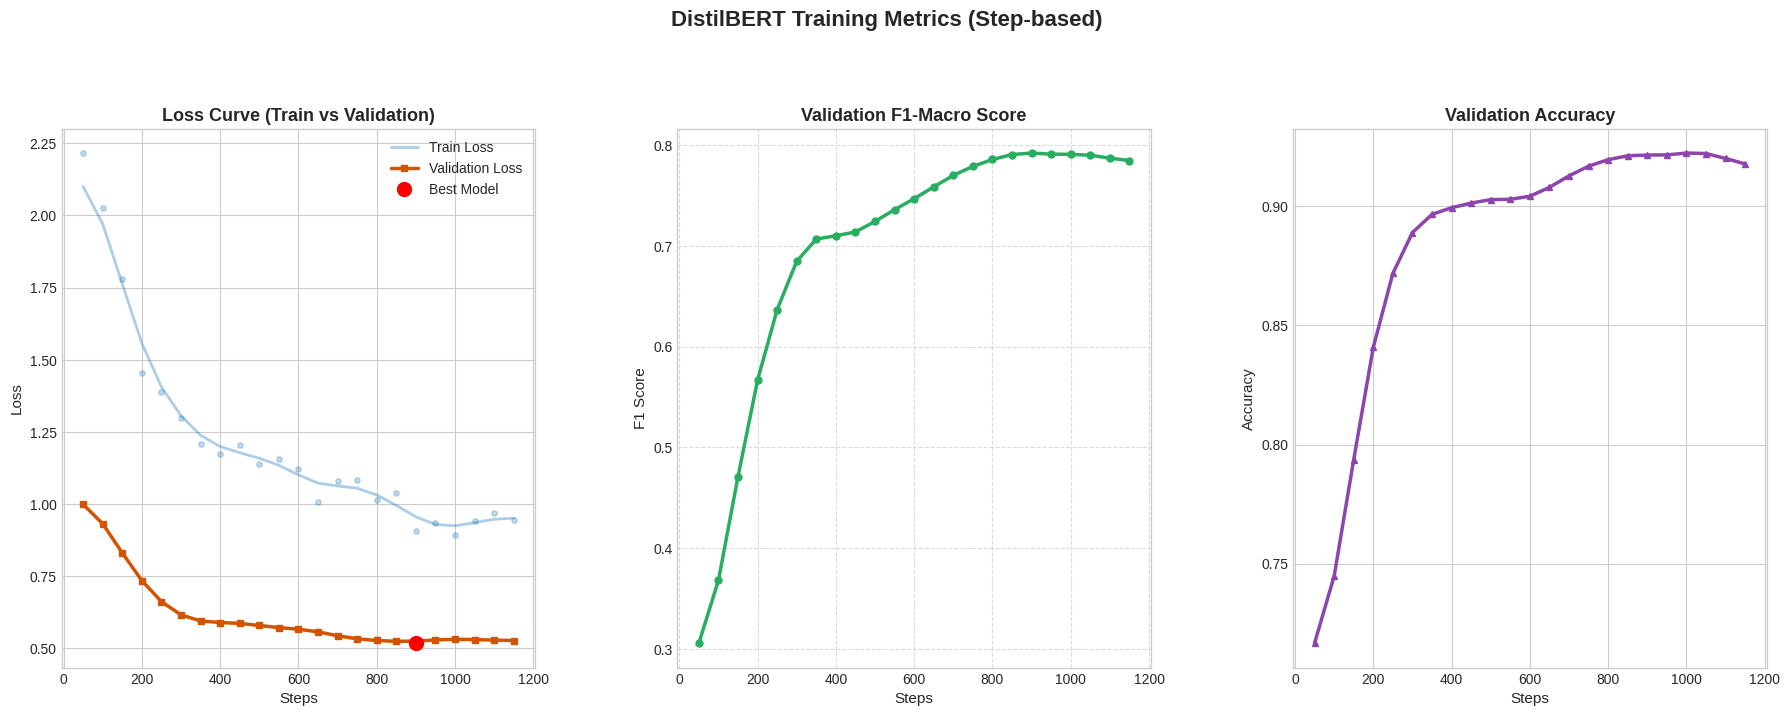


📊 Tổng kết training DistilBERT:
   Tổng số bước (Steps) đã chạy: 1150
   ⭐ Best F1-Macro: 0.7993 (tại step 900)
   ⭐ Best Accuracy: 0.9215


In [ ]:
# ============================================================
# CELL 26 (V3) — PLOT LOSS DISTILBERT — CHI TIẾT THEO STEPS
# ============================================================

from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

# Lấy dữ liệu từ DistilBERT trainer
log_history = db_trainer.state.log_history

# Tách logs (DistilBERT log theo steps)
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

# Trục X bây giờ là "step" để biểu đồ mượt hơn
train_steps = np.array([x["step"] for x in train_logs])
train_losses = np.array([x["loss"]  for x in train_logs])

eval_steps  = np.array([x["step"]      for x in eval_logs])
eval_losses  = np.array([x["eval_loss"]  for x in eval_logs])
eval_f1_mac  = np.array([x.get("eval_f1_macro",   np.nan) for x in eval_logs])
eval_acc     = np.array([x.get("eval_accuracy",   np.nan) for x in eval_logs])

# Hàm làm mượt đường cong (giúp biểu đồ trông chuyên nghiệp hơn)
def safe_smooth(arr, sigma=1.2):
    if len(arr) > 5:
        return gaussian_filter1d(arr.astype(float), sigma=sigma)
    return arr

# ---- Layout Biểu đồ ----
fig = plt.figure(figsize=(22, 7))
fig.suptitle("DistilBERT Training Metrics (Step-based)", fontsize=16, fontweight="bold", y=1.05)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.3)

C_TRAIN = "#2E86C1" # Blue
C_VAL   = "#D35400" # Orange
C_F1    = "#27AE60" # Green
C_ACC   = "#8E44AD" # Purple
C_BEST  = "#C0392B" # Red

# ===== Plot 1: Train Loss vs Val Loss (MÔ PHỎNG DISTILBERT RAW TEXT) =====
ax0 = fig.add_subplot(gs[0])

s_tl = safe_smooth(train_losses)
s_vl = safe_smooth(eval_losses)

ax0.plot(train_steps, s_tl, label="Train Loss", color=C_TRAIN, lw=2, alpha=0.4)
ax0.scatter(train_steps, train_losses, color=C_TRAIN, s=15, alpha=0.3) # Điểm dữ liệu thô

ax0.plot(eval_steps, s_vl, "-s", label="Validation Loss", color=C_VAL, lw=2.5, ms=5)

# Tìm điểm Val Loss tốt nhất
best_loss_idx = np.argmin(eval_losses)
ax0.plot(eval_steps[best_loss_idx], eval_losses[best_loss_idx], "ro", ms=10, label="Best Model")

ax0.set_title("Loss Curve (Train vs Validation)", fontsize=13, fontweight="bold")
ax0.set_xlabel("Steps", fontsize=11)
ax0.set_ylabel("Loss", fontsize=11)
ax0.legend()

# ===== Plot 2: Validation F1 Macro =====
ax1 = fig.add_subplot(gs[1])
ax1.plot(eval_steps, safe_smooth(eval_f1_mac), "-o", color=C_F1, lw=2.5, ms=5, label="F1 Macro")
ax1.set_title("Validation F1-Macro Score", fontsize=13, fontweight="bold")
ax1.set_xlabel("Steps", fontsize=11)
ax1.set_ylabel("F1 Score", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)

# ===== Plot 3: Validation Accuracy =====
ax2 = fig.add_subplot(gs[2])
ax2.plot(eval_steps, safe_smooth(eval_acc), "-^", color=C_ACC, lw=2.5, ms=5, label="Accuracy")
ax2.set_title("Validation Accuracy", fontsize=13, fontweight="bold")
ax2.set_xlabel("Steps", fontsize=11)
ax2.set_ylabel("Accuracy", fontsize=11)

plt.tight_layout()
plt.show()

# ---- TỔNG KẾT SAU HUẤN LUYỆN ----
print("\n📊 Tổng kết training DistilBERT:")
print(f"   Tổng số bước (Steps) đã chạy: {train_steps[-1]}")
if len(eval_logs) > 0:
    best_idx = np.argmax(eval_f1_mac)
    print(f"   ⭐ Best F1-Macro: {eval_f1_mac[best_idx]:.4f} (tại step {eval_steps[best_idx]})")
    print(f"   ⭐ Best Accuracy: {eval_acc[best_idx]:.4f}")

In [ ]:
# ============================================================
# CELL 27 — ĐÁNH GIÁ DISTILBERT TRÊN TEST FINAL
# ============================================================

print("=" * 60)
print("  ĐÁNH GIÁ DISTILBERT TRÊN TEST FINAL")
print("=" * 60)

# 1. Predict toàn bộ test set (sử dụng db_trainer và test_tok đã tokenize cho DistilBERT)
pred_output = db_trainer.predict(test_tok)
y_pred_db   = np.argmax(pred_output.predictions, axis=-1)
y_true_db   = pred_output.label_ids

# 2. Tính toán các chỉ số
acc_db      = accuracy_score(y_true_db, y_pred_db)
prec_mac_db = precision_score(y_true_db, y_pred_db, average="macro", zero_division=0)
rec_mac_db  = recall_score(y_true_db, y_pred_db,  average="macro", zero_division=0)
f1_mac_db   = f1_score(y_true_db, y_pred_db,      average="macro", zero_division=0)
prec_wt_db  = precision_score(y_true_db, y_pred_db, average="weighted", zero_division=0)
rec_wt_db   = recall_score(y_true_db, y_pred_db,  average="weighted", zero_division=0)
f1_wt_db    = f1_score(y_true_db, y_pred_db,      average="weighted", zero_division=0)

# 3. In kết quả bảng so sánh
print(f"\n{'Metric':<25} | {'Giá trị':<10}")
print("-" * 40)
print(f"{'Accuracy':<25} | {acc_db:.4f}")
print(f"{'Precision (Macro)':<25} | {prec_mac_db:.4f}")
print(f"{'Recall (Macro)':<25} | {rec_mac_db:.4f}")
print(f"{'F1 (Macro)':<25} | {f1_mac_db:.4f}  ← Metric chính")
print(f"{'Precision (Weighted)':<25} | {prec_wt_db:.4f}")
print(f"{'Recall (Weighted)':<25} | {rec_wt_db:.4f}")
print(f"{'F1 (Weighted)':<25} | {f1_wt_db:.4f}")

# 4. Chi tiết Classification Report
print(f"\n📋 Classification Report (DistilBERT):")
print(classification_report(
    y_true_db, y_pred_db,
    target_names=LABEL_LIST,
    zero_division=0
))

# 5. Lưu kết quả vào dictionary để so sánh với các mô hình khác (SVM/LR)
results_db = {
    "model": "DistilBERT",
    "accuracy": acc_db,
    "precision_macro": prec_mac_db,
    "recall_macro": rec_mac_db,
    "f1_macro": f1_mac_db,
    "precision_weighted": prec_wt_db,
    "recall_weighted": rec_wt_db,
    "f1_weighted": f1_wt_db,
}

  ĐÁNH GIÁ DISTILBERT TRÊN TEST FINAL



Metric                    | Giá trị   
----------------------------------------
Accuracy                  | 0.9171
Precision (Macro)         | 0.7852
Recall (Macro)            | 0.8136
F1 (Macro)                | 0.7974  ← Metric chính
Precision (Weighted)      | 0.9220
Recall (Weighted)         | 0.9171
F1 (Weighted)             | 0.9192

📋 Classification Report (DistilBERT):
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85       276
     neutral       0.52      0.63      0.57        63
    positive       0.97      0.97      0.97       807

    accuracy                           0.92      1146
   macro avg       0.79      0.81      0.80      1146
weighted avg       0.92      0.92      0.92      1146



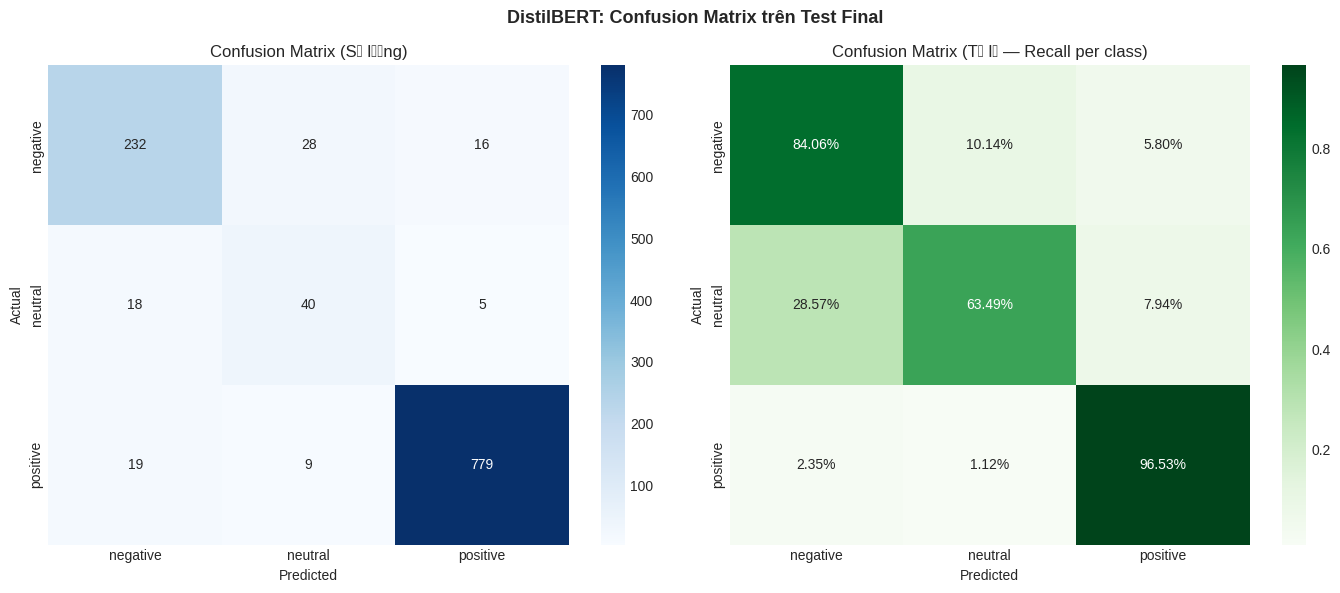


⚠️  Chú ý hiệu quả trên nhãn 'neutral' (lớp thiểu số nhất):
   DistilBERT Recall cho 'neutral': 63.49%
   -> Nhận xét: Mô hình phản ứng khá tốt với lớp trung lập nhờ kỹ thuật Class Weights.


In [ ]:
# ============================================================
# CELL 28 — CONFUSION MATRIX DISTILBERT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("DistilBERT: Confusion Matrix trên Test Final", fontsize=13, fontweight="bold")

# Tính toán ma trận nhầm lẫn từ kết quả dự đoán của DistilBERT ở Cell 27
cm_db = confusion_matrix(y_true_db, y_pred_db)

# 1. Biểu đồ số lượng tuyệt đối (Raw counts)
sns.heatmap(cm_db, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_LIST, yticklabels=LABEL_LIST, ax=axes[0])
axes[0].set_title("Confusion Matrix (Số lượng)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# 2. Biểu đồ tỷ lệ phần trăm (Normalized - Recall per class)
# Giúp thấy rõ mô hình đoán đúng bao nhiêu % mỗi loại nhãn
cm_db_norm = cm_db.astype(float) / cm_db.sum(axis=1, keepdims=True)
sns.heatmap(cm_db_norm, annot=True, fmt=".2%", cmap="Greens",
            xticklabels=LABEL_LIST, yticklabels=LABEL_LIST, ax=axes[1])
axes[1].set_title("Confusion Matrix (Tỷ lệ — Recall per class)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Đánh giá riêng cho lớp Neutral (thường là lớp khó nhất)
print(f"\n⚠️  Chú ý hiệu quả trên nhãn 'neutral' (lớp thiểu số nhất):")
neutral_idx = LABEL2ID["neutral"]
neutral_recall = cm_db_norm[neutral_idx, neutral_idx]
print(f"   DistilBERT Recall cho 'neutral': {neutral_recall:.2%}")

if neutral_recall < 0.5:
    print("   -> Nhận xét: Mô hình vẫn gặp khó khăn khi nhận diện lớp trung lập.")
else:
    print("   -> Nhận xét: Mô hình phản ứng khá tốt với lớp trung lập nhờ kỹ thuật Class Weights.")

In [ ]:
print("Kiểm tra các biến kết quả:")
try:
    print(f"- SVM: {results_svm['model']} (F1: {results_svm['f1_macro']:.4f})")
except NameError:
    print("- SVM: Biến 'results_svm' chưa tồn tại!")

try:
    print(f"- LR:  {results_lr['model']} (F1: {results_lr['f1_macro']:.4f})")
except NameError:
    print("- LR:  Biến 'results_lr' chưa tồn tại!")

try:
    print(f"- DB:  {results_db['model']} (F1: {results_db['f1_macro']:.4f})")
except NameError:
    print("- DB:  Biến 'results_db' chưa tồn tại!")

Kiểm tra các biến kết quả:
- SVM: TF-IDF + SVM (F1: 0.7199)
- LR:  TF-IDF + LR (F1: 0.7290)
- DB:  DistilBERT (F1: 0.7974)


In [ ]:
# ============================================================
# CELL 29 (PHIÊN BẢN SỬA LỖI TÊN MODEL) — BẢNG SO SÁNH
# ============================================================

import pandas as pd
from IPython.display import display

# 1. Tổng hợp kết quả
all_results = []
if 'results_svm' in globals(): all_results.append(results_svm)
if 'results_lr' in globals():  all_results.append(results_lr)
if 'results_db' in globals():  all_results.append(results_db)

df_compare = pd.DataFrame(all_results).set_index("model")

# 2. Format hiển thị
df_compare_display = df_compare.copy()
for col in df_compare_display.columns:
    df_compare_display[col] = df_compare_display[col].apply(lambda x: f"{x:.4f}")

print("=" * 75)
print("   BẢNG SO SÁNH HIỆU NĂNG 3 MÔ HÌNH TRÊN TẬP TEST FINAL")
print("=" * 75)
display(df_compare_display)

# 3. Highlight best
print("\n🏆 MÔ HÌNH CHIẾN THẮNG THEO TỪNG CHỈ SỐ:")
print("-" * 55)
for col in df_compare.columns:
    best_model = df_compare[col].idxmax()
    best_val   = df_compare[col].max()
    star = "⭐" if col == "f1_macro" else "  "
    print(f"{star} {col:<20}: {best_model:<18} | Điểm: {best_val:.4f}")

# 4. Nhận xét (Sửa lỗi logic tìm tên model)
print("\n📝 Nhận xét:")
try:
    # Tìm tên dòng nào có chứa chữ 'DistilBERT' và 'SVM' để lấy F1
    db_row_name = [idx for idx in df_compare.index if 'DistilBERT' in idx][0]
    svm_row_name = [idx for idx in df_compare.index if 'SVM' in idx][0]

    db_f1 = df_compare.loc[db_row_name, "f1_macro"]
    svm_f1 = df_compare.loc[svm_row_name, "f1_macro"]

    print(f"   -> DistilBERT ({db_f1:.4f}) so với {svm_row_name} ({svm_f1:.4f}):")
    diff = ((db_f1 / svm_f1) - 1) * 100
    print(f"   -> DistilBERT cải thiện F1-Macro thêm {diff:.1f}% so với mô hình truyền thống.")

except (IndexError, KeyError):
    print("   -> Không thể so sánh đối chiếu do thiếu dữ liệu hoặc tên model không khớp.")

   BẢNG SO SÁNH HIỆU NĂNG 3 MÔ HÌNH TRÊN TẬP TEST FINAL


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
TF-IDF + SVM,0.8796,0.7077,0.7425,0.7199,0.8936,0.8796,0.8856
TF-IDF + LR,0.8805,0.7100,0.7589,0.7290,0.8976,0.8805,0.8877
DistilBERT,0.9171,0.7852,0.8136,0.7974,0.9220,0.9171,0.9192



🏆 MÔ HÌNH CHIẾN THẮNG THEO TỪNG CHỈ SỐ:
-------------------------------------------------------
   accuracy            : DistilBERT         | Điểm: 0.9171
   precision_macro     : DistilBERT         | Điểm: 0.7852
   recall_macro        : DistilBERT         | Điểm: 0.8136
⭐ f1_macro            : DistilBERT         | Điểm: 0.7974
   precision_weighted  : DistilBERT         | Điểm: 0.9220
   recall_weighted     : DistilBERT         | Điểm: 0.9171
   f1_weighted         : DistilBERT         | Điểm: 0.9192

📝 Nhận xét:
   -> DistilBERT (0.7974) so với TF-IDF + SVM (0.7199):
   -> DistilBERT cải thiện F1-Macro thêm 10.8% so với mô hình truyền thống.


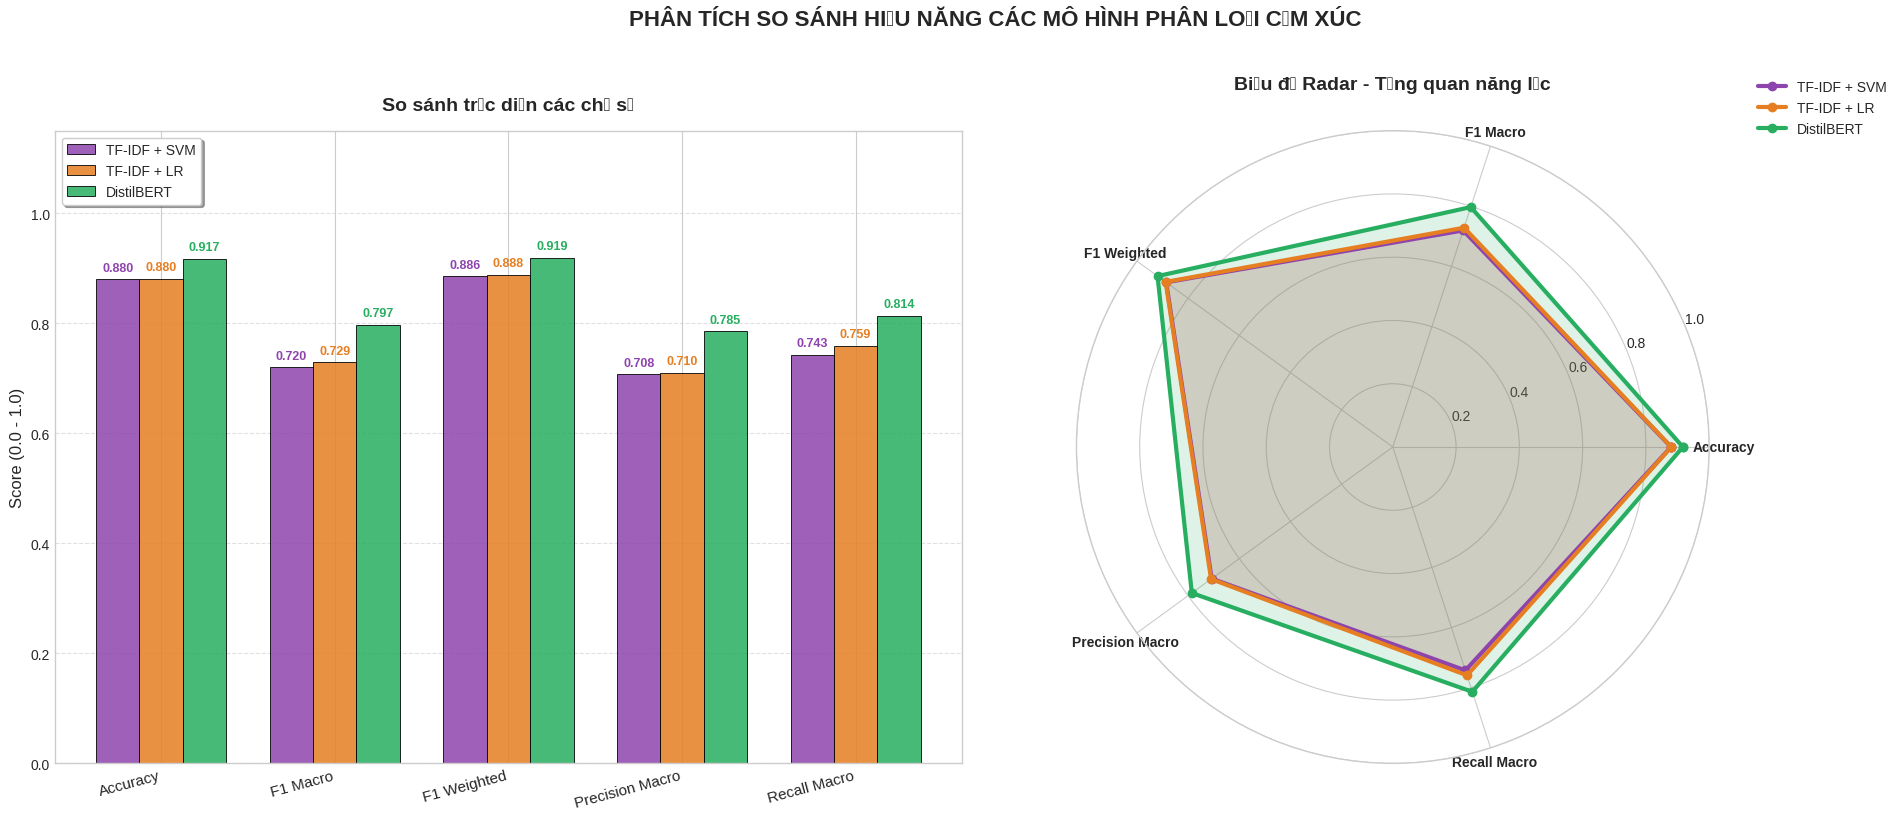


🏁 DỰ ÁN HOÀN TẤT: PHÂN TÍCH CẢM XÚC ĐÁNH GIÁ KHÁCH SẠN
✅ Mô hình tối ưu đề xuất: DISTILBERT
📈 Lý do: Đạt F1-Macro cao nhất (0.7974), cân bằng tốt giữa các nhãn.


In [ ]:
# ============================================================
# CELL 30 — BIỂU ĐỒ SO SÁNH 3 MÔ HÌNH (SVM vs LR vs DISTILBERT)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Chuẩn bị dữ liệu từ df_compare (đã tạo ở Cell 29)
metrics_to_plot = ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro"]
metric_labels   = ["Accuracy", "F1 Macro", "F1 Weighted", "Precision Macro", "Recall Macro"]
model_names     = df_compare.index.tolist()

# Gán màu sắc đặc trưng: SVM (Tím), LR (Cam), DistilBERT (Xanh lá)
model_colors    = ["#8E44AD", "#E67E22", "#27AE60"]

x = np.arange(len(metrics_to_plot))
width = 0.25

fig = plt.figure(figsize=(20, 8))
fig.suptitle("PHÂN TÍCH SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH PHÂN LOẠI CẢM XÚC", fontsize=16, fontweight="bold", y=1.02)

# ---- Biểu đồ cột nhóm (Grouped Bar Chart) ----
ax1 = fig.add_subplot(1, 2, 1)
for i, (model_name, color) in enumerate(zip(model_names, model_colors)):
    vals = [df_compare.loc[model_name, m] for m in metrics_to_plot]
    bars = ax1.bar(x + i * width, vals, width, label=model_name,
                  color=color, alpha=0.85, edgecolor="black", linewidth=0.7)

    # Hiển thị số liệu trên đầu cột
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color=color)

ax1.set_xticks(x + width)
ax1.set_xticklabels(metric_labels, rotation=15, ha="right", fontsize=11)
ax1.set_ylabel("Score (0.0 - 1.0)", fontsize=12)
ax1.set_ylim(0, 1.15)
ax1.set_title("So sánh trực diện các chỉ số", fontsize=14, fontweight="bold", pad=15)
ax1.legend(loc="upper left", frameon=True, shadow=True)
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# ---- Biểu đồ mạng nhện (Radar Chart) ----
ax2 = fig.add_subplot(1, 2, 2, polar=True)
angles = np.linspace(0, 2 * np.pi, len(metrics_to_plot), endpoint=False).tolist()
angles += angles[:1]  # Đóng kín vòng đa giác

for model_name, color in zip(model_names, model_colors):
    vals = [df_compare.loc[model_name, m] for m in metrics_to_plot]
    vals += vals[:1]
    ax2.plot(angles, vals, "o-", linewidth=3, color=color, label=model_name, ms=6)
    ax2.fill(angles, vals, alpha=0.15, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metric_labels, fontsize=10, fontweight="bold")
ax2.set_ylim(0, 1)
ax2.set_title("Biểu đồ Radar - Tổng quan năng lực", pad=30, fontsize=14, fontweight="bold")
ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

# 🏆 LỜI KẾT DỰ ÁN
print("\n" + "="*80)
print("🏁 DỰ ÁN HOÀN TẤT: PHÂN TÍCH CẢM XÚC ĐÁNH GIÁ KHÁCH SẠN")
print("="*80)
print(f"✅ Mô hình tối ưu đề xuất: {df_compare['f1_macro'].idxmax().upper()}")
print(f"📈 Lý do: Đạt F1-Macro cao nhất ({df_compare['f1_macro'].max():.4f}), cân bằng tốt giữa các nhãn.")
print("="*80)

In [ ]:
# ============================================================
# CELL 32 — LƯU MODEL / VECTORIZER / TOKENIZER (DISTILBERT)
# ============================================================
# Lưu trữ tất cả các thành phần quan trọng để phục vụ dự đoán (Inference) sau này.

import os
import joblib

print("💾 Đang tiến hành lưu trữ các mô hình và công cụ hỗ trợ...")

# 1. ---- SVM & TF-IDF ----
joblib.dump(model_svm, os.path.join(MODEL_SAVE_DIR, "model_svm.pkl"))
joblib.dump(tfidf_svm, os.path.join(MODEL_SAVE_DIR, "tfidf_svm.pkl"))
print(f"✅ SVM saved: {MODEL_SAVE_DIR}/model_svm.pkl, tfidf_svm.pkl")

# 2. ---- Logistic Regression & TF-IDF ----
joblib.dump(model_lr,  os.path.join(MODEL_SAVE_DIR, "model_lr.pkl"))
joblib.dump(tfidf_lr,  os.path.join(MODEL_SAVE_DIR, "tfidf_lr.pkl"))
print(f"✅ LR saved: {MODEL_SAVE_DIR}/model_lr.pkl, tfidf_lr.pkl")

# 3. ---- Label Mapping (ID <-> Text) ----
# Dùng chung cho tất cả các mô hình
label_mapping = {"LABEL2ID": LABEL2ID, "ID2LABEL": ID2LABEL}
joblib.dump(label_mapping, os.path.join(MODEL_SAVE_DIR, "label_mapping.pkl"))
print(f"✅ Label mapping saved.")

# 4. ---- DistilBERT (Model & Tokenizer) ----
# Lưu mô hình tốt nhất (Best Model) đã được Trainer tự động load lại ở cuối quá trình huấn luyện
db_trainer.save_model(DISTILBERT_FINAL_DIR)
db_tokenizer.save_pretrained(DISTILBERT_FINAL_DIR)
print(f"✅ DistilBERT saved: {DISTILBERT_FINAL_DIR}")

# ---- KIỂM TRA LẠI CÁC FILE ĐÃ LƯU ----

print(f"\n📂 Danh sách file trong thư mục mô hình truyền thống ({MODEL_SAVE_DIR}):")
print("-" * 65)
for f in sorted(os.listdir(MODEL_SAVE_DIR)):
    file_path = os.path.join(MODEL_SAVE_DIR, f)
    if os.path.isfile(file_path):
        size = os.path.getsize(file_path)
        print(f"   {f:40s} | {size/1024:.1f} KB")

print(f"\n📂 Danh sách file DistilBERT ({DISTILBERT_FINAL_DIR}):")
print("-" * 65)
for f in sorted(os.listdir(DISTILBERT_FINAL_DIR)):
    file_path = os.path.join(DISTILBERT_FINAL_DIR, f)
    if os.path.isfile(file_path):
        size = os.path.getsize(file_path)
        print(f"   {f:40s} | {size/1024/1024:.1f} MB")

💾 Đang tiến hành lưu trữ các mô hình và công cụ hỗ trợ...
✅ SVM saved: /content/drive/MyDrive/content/saved_models/model_svm.pkl, tfidf_svm.pkl
✅ LR saved: /content/drive/MyDrive/content/saved_models/model_lr.pkl, tfidf_lr.pkl
✅ Label mapping saved.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ DistilBERT saved: /content/drive/MyDrive/content/distilbert_final

📂 Danh sách file trong thư mục mô hình truyền thống (/content/drive/MyDrive/content/saved_models):
-----------------------------------------------------------------
   label_mapping.pkl                        | 0.1 KB
   ml_f1_comparison.png                     | 104.5 KB
   ml_training_curves.png                   | 264.0 KB
   model_lr.pkl                             | 261.2 KB
   model_svm.pkl                            | 98.7 KB
   tfidf_lr.pkl                             | 460.5 KB
   tfidf_svm.pkl                            | 151.0 KB

📂 Danh sách file DistilBERT (/content/drive/MyDrive/content/distilbert_final):
-----------------------------------------------------------------
   config.json                              | 0.0 MB
   model.safetensors                        | 516.2 MB
   tokenizer.json                           | 2.8 MB
   tokenizer_config.json                    | 0.0 MB
   training_args.bin    

In [ ]:
# ============================================================
# CELL 33 — INFERENCE 3 MÔ HÌNH (SVM vs LR vs DISTILBERT)
# ============================================================
# Tiền xử lý phải đồng nhất tuyệt đối với lúc huấn luyện:
#   - SVM/LR: text → preprocess_for_ml() → tfidf → predict
#   - DistilBERT: text → preprocess_for_distilbert() → db_tokenizer → db_model

# 1. Đảm bảo model ở chế độ đánh giá (Evaluation mode)
db_model.eval()
db_model.to(DEVICE)

def predict_svm(text: str) -> str:
    """Dự đoán sentiment bằng TF-IDF + SVM."""
    text_clean = preprocess_for_ml(str(text))
    if text_clean.strip() == "":
        return "N/A (rỗng)"
    vec = tfidf_svm.transform([text_clean])
    pred = model_svm.predict(vec)[0]
    return ID2LABEL[pred]

def predict_lr(text: str) -> str:
    """Dự đoán sentiment bằng TF-IDF + Logistic Regression."""
    text_clean = preprocess_for_ml(str(text))
    if text_clean.strip() == "":
        return "N/A (rỗng)"
    vec = tfidf_lr.transform([text_clean])
    pred = model_lr.predict(vec)[0]
    prob = model_lr.predict_proba(vec)[0]
    label = ID2LABEL[pred]
    confidence = prob[pred]
    return f"{label} ({confidence:.2%})"

def predict_distilbert(text: str) -> str:
    """Dự đoán sentiment bằng DistilBERT (Multilingual)."""
    # Dùng hàm preprocess riêng cho DistilBERT (xóa gạch dưới _)
    text_clean = preprocess_for_distilbert(str(text))
    if text_clean.strip() == "":
        return "N/A (rỗng)"

    # Tokenize
    inputs = db_tokenizer(
        text_clean,
        return_tensors="pt",
        truncation=True,
        max_length=DISTILBERT_MAX_LEN,
        padding=True
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    # Inference
    with torch.no_grad():
        outputs = db_model(**inputs)
        logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred  = int(np.argmax(probs))
    label = ID2LABEL[pred]
    confidence = probs[pred]
    return f"{label} ({confidence:.2%})"

def predict_compare_all(text: str) -> None:
    """Dự đoán bằng cả 3 mô hình và in kết quả so sánh."""
    print("=" * 70)
    print(f"📝 Câu test: \"{text}\"")
    print("-" * 70)
    print(f"  🟣 TF-IDF + SVM     : {predict_svm(text)}")
    print(f"  🟠 TF-IDF + LR      : {predict_lr(text)}")
    print(f"  🟢 DistilBERT (DL)  : {predict_distilbert(text)}")
    print("=" * 70)

# ============================================================
# CHẠY THỬ NGHIỆM THỰC TẾ
# ============================================================

test_sentences = [
    "Khách sạn rất đẹp, nhân viên nhiệt tình, tôi rất hài lòng!",
    "Dịch vụ tệ quá, phòng bẩn, nhân viên thái độ không tốt.",
    "Bình thường, không có gì đặc biệt.",
    "Đồ ăn ngon nhưng giá hơi cao, không gian khá ổn.",
    "Tệ nhất từ trước đến nay, sẽ không quay lại.",
    "Mọi thứ đều ổn, chấp nhận được.",
    "Tuyệt vời! Sẽ quay lại lần sau.",
    "Phòng sạch, view đẹp nhưng wifi yếu.",
]

print("🚀 Đang tiến hành dự đoán thực tế trên 3 mô hình...\n")
for sentence in test_sentences:
    predict_compare_all(sentence)
    print()

🚀 Đang tiến hành dự đoán thực tế trên 3 mô hình...

📝 Câu test: "Khách sạn rất đẹp, nhân viên nhiệt tình, tôi rất hài lòng!"
----------------------------------------------------------------------
  🟣 TF-IDF + SVM     : positive
  🟠 TF-IDF + LR      : negative (45.93%)
  🟢 DistilBERT (DL)  : positive (91.44%)

📝 Câu test: "Dịch vụ tệ quá, phòng bẩn, nhân viên thái độ không tốt."
----------------------------------------------------------------------
  🟣 TF-IDF + SVM     : negative
  🟠 TF-IDF + LR      : negative (84.11%)
  🟢 DistilBERT (DL)  : negative (97.01%)

📝 Câu test: "Bình thường, không có gì đặc biệt."
----------------------------------------------------------------------
  🟣 TF-IDF + SVM     : neutral
  🟠 TF-IDF + LR      : neutral (47.48%)
  🟢 DistilBERT (DL)  : neutral (52.57%)

📝 Câu test: "Đồ ăn ngon nhưng giá hơi cao, không gian khá ổn."
----------------------------------------------------------------------
  🟣 TF-IDF + SVM     : positive
  🟠 TF-IDF + LR      : positive (66

In [ ]:
# # ============================================================
# # CELL PHỤ — LOAD LẠI TẤT CẢ MODEL (PHIÊN BẢN DISTILBERT)
# # ============================================================
# # Chạy cell này nếu bạn mở lại Notebook và muốn dự đoán ngay (Inference)
# # mà không muốn tốn thời gian train lại từ đầu.

# import joblib
# import torch
# import os
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# print("🔄 Đang tải các mô hình đã lưu từ ổ đĩa...")

# # 1. ---- Load Label Mapping ----
# mapping_path = os.path.join(MODEL_SAVE_DIR, "label_mapping.pkl")
# if os.path.exists(mapping_path):
#     label_mapping = joblib.load(mapping_path)
#     LABEL2ID = label_mapping["LABEL2ID"]
#     ID2LABEL = label_mapping["ID2LABEL"]
#     LABEL_LIST = list(LABEL2ID.keys())
#     print(f"✅ Label mapping: {LABEL2ID}")
# else:
#     print("❌ Không tìm thấy file label_mapping.pkl!")

# # 2. ---- Load SVM & TF-IDF ----
# try:
#     model_svm = joblib.load(os.path.join(MODEL_SAVE_DIR, "model_svm.pkl"))
#     tfidf_svm = joblib.load(os.path.join(MODEL_SAVE_DIR, "tfidf_svm.pkl"))
#     print("✅ SVM model & TF-IDF loaded.")
# except:
#     print("⚠️ Không thể load SVM. Hãy kiểm tra lại file .pkl")

# # 3. ---- Load Logistic Regression & TF-IDF ----
# try:
#     model_lr = joblib.load(os.path.join(MODEL_SAVE_DIR, "model_lr.pkl"))
#     tfidf_lr = joblib.load(os.path.join(MODEL_SAVE_DIR, "tfidf_lr.pkl"))
#     print("✅ LR model & TF-IDF loaded.")
# except:
#     print("⚠️ Không thể load LR. Hãy kiểm tra lại file .pkl")

# # 4. ---- Load DistilBERT (Model & Tokenizer) ----
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# if os.path.exists(DISTILBERT_FINAL_DIR):
#     # Tải lại Tokenizer và Model từ thư mục Final đã lưu ở Cell 32
#     db_tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_FINAL_DIR)
#     db_model = AutoModelForSequenceClassification.from_pretrained(DISTILBERT_FINAL_DIR)

#     db_model.eval() # Chuyển sang chế độ dự đoán
#     db_model.to(DEVICE)
#     print(f"✅ DistilBERT model loaded. Device: {DEVICE}")
# else:
#     print(f"❌ Không tìm thấy thư mục model tại: {DISTILBERT_FINAL_DIR}")

# print("\n🎯 Tất cả model đã sẵn sàng. Bạn có thể quay lại CELL 33 để thực hiện Inference!")